In [1]:
import pandas as pd
import numpy as np
from matplotlib.ticker import LogFormatter
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import json
import sys
import plategig
import re

# Path ported for the Nature Communications public reproducibility archive.
# Original (UTSW BioHPC cluster): /project/greencenter/Toprak_lab/shared/plategig/projects/Tested_Variants_MIC_Estimations
PROJECT_PATH = Path.cwd()
PROJECT_ID = '.'

#### Step 1: Read Plate Information

In [2]:
# Read the Excel file into a DataFrame
df_plate_info = pd.read_excel(PROJECT_PATH / PROJECT_ID / 'data' / 'PlateInfo_250508_250510_250407.xlsx', engine='openpyxl')
df_plate_info.rename(columns={'Plate': 'Plate_ID'}, inplace=True)
df_plate_info

,Experiment,Plate_ID,Well,Strain,Culture,Replicate,Antibiotic,Dose
0,1,1,A1,Media Only,NaN,NaN,NaN,NaN
1,1,1,A2,Media Only,NaN,NaN,NaN,NaN
2,1,1,A3,Media Only,NaN,NaN,NaN,NaN
3,1,1,A4,Media Only,NaN,NaN,NaN,NaN
4,1,1,A5,Media Only,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
3547,1,37,H8,Media Only,NaN,NaN,NaN,NaN
3548,1,37,H9,Media Only,NaN,NaN,NaN,NaN
3549,1,37,H10,Media Only,NaN,NaN,NaN,NaN
3550,1,37,H11,Media Only,NaN,NaN,NaN,NaN


Collect unique plate IDs

#### Step 2: Read the raw OD data

In [3]:
df_OD_raw = pd.read_excel(PROJECT_PATH / PROJECT_ID / 'data' /'ODFinal_250508_250510_250407.xlsx')
# drop last nan column, fix to input mistake
df_OD_raw = df_OD_raw.iloc[:,:-4]
df_OD_raw.tail()

,Unnamed: 0,1,2,3,4,5,6,7,8,9,10,11,12
363,D,0.046,0.047,0.048,0.047,0.047,0.049,0.272,0.353,0.384,0.320,0.330,0.784
364,E,0.045,0.045,0.045,0.045,0.045,0.045,0.045,0.045,0.045,0.045,0.045,0.046
365,F,0.045,0.045,0.045,0.046,0.047,0.044,0.045,0.046,0.046,0.046,0.046,0.046
366,G,0.047,0.046,0.047,0.045,0.045,0.045,0.045,0.045,0.046,0.046,0.048,0.047
367,H,0.047,0.045,0.046,0.045,0.045,0.045,0.045,0.046,0.045,0.047,0.045,0.046


In [4]:
df = plategig.static.convert_OD_plate_to_long(df_OD_raw, df_plate_info)
df

,Plate_ID,Well,OD,Row,Column
0,1,A1,0.048,1,1
1,1,A2,0.051,1,2
2,1,A3,0.048,1,3
3,1,A4,0.050,1,4
4,1,A5,0.048,1,5
...,...,...,...,...,...
3547,37,H8,0.046,8,8
3548,37,H9,0.045,8,9
3549,37,H10,0.047,8,10
3550,37,H11,0.045,8,11


Calculate median background of all plates to impute plates with missing media-only wells.

In [5]:
df_plate_info[df_plate_info['Strain']=='Media Only']

,Experiment,Plate_ID,Well,Strain,Culture,Replicate,Antibiotic,Dose
0,1,1,A1,Media Only,NaN,NaN,NaN,NaN
1,1,1,A2,Media Only,NaN,NaN,NaN,NaN
2,1,1,A3,Media Only,NaN,NaN,NaN,NaN
3,1,1,A4,Media Only,NaN,NaN,NaN,NaN
4,1,1,A5,Media Only,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
3547,1,37,H8,Media Only,NaN,NaN,NaN,NaN
3548,1,37,H9,Media Only,NaN,NaN,NaN,NaN
3549,1,37,H10,Media Only,NaN,NaN,NaN,NaN
3550,1,37,H11,Media Only,NaN,NaN,NaN,NaN


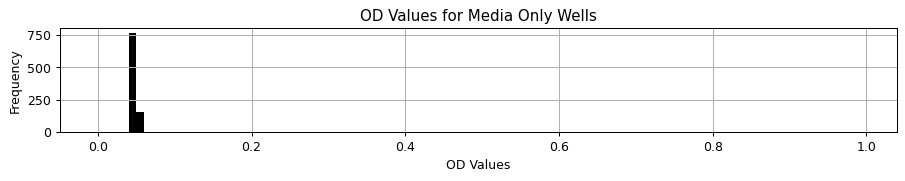

0.048


In [6]:
median_background_all_plates = plategig.static.calc_median_background_all_plates(
    df, df_plate_info, plot=True)
#I had to make these changes because there was a problem with the plate map info, confirm with Adam.
print(median_background_all_plates)

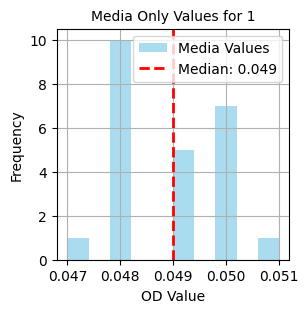

np.float64(0.049)

In [7]:
plategig.static.plot_single_plate_media_only_wells(df, df_plate_info, plate_id=1, column_name='OD')

Apply background correction for all plates

In [8]:
df_bc = df.copy()
df_bc['OD_final'] = df_bc['OD'] - median_background_all_plates

#### Evaluate growth metrics

In [9]:
df_bc

,Plate_ID,Well,OD,Row,Column,OD_final
0,1,A1,0.048,1,1,0.000
1,1,A2,0.051,1,2,0.003
2,1,A3,0.048,1,3,0.000
3,1,A4,0.050,1,4,0.002
4,1,A5,0.048,1,5,0.000
...,...,...,...,...,...,...
3547,37,H8,0.046,8,8,-0.002
3548,37,H9,0.045,8,9,-0.003
3549,37,H10,0.047,8,10,-0.001
3550,37,H11,0.045,8,11,-0.003


In [10]:
# Prep the analysis dataframe
df_analysis = pd.merge(df_plate_info, df_bc, on=['Plate_ID', 'Well'])
df_analysis = df_analysis[['Experiment','Strain', 'Culture', 'Replicate', 'Antibiotic',
                           'Dose', 'Plate_ID', 'Well', 'Row', 'Column',
                           'OD', 'OD_final']]
# Remove control wells
df_analysis = df_analysis[~df_analysis['Strain'].isin(['Media Only','Cells Only'])]
# Keep group names
df_analysis['Group'] = df_analysis.Strain
# Define each culture of as a separate strain
# df_analysis['Strain'] = df_analysis.Strain + df_analysis.Culture.astype(int).astype(str)
df_analysis


,Experiment,Strain,Culture,Replicate,Antibiotic,Dose,Plate_ID,Well,Row,Column,OD,OD_final,Group
12,1,NEB10B,1.0,1.0,Ampicillin,30000.000000,1,B1,2,1,0.042,-0.006,NEB10B
13,1,NEB10B,1.0,1.0,Ampicillin,10000.000000,1,B2,2,2,0.043,-0.005,NEB10B
14,1,NEB10B,1.0,1.0,Ampicillin,3333.333330,1,B3,2,3,0.043,-0.005,NEB10B
15,1,NEB10B,1.0,1.0,Ampicillin,1111.111110,1,B4,2,4,0.043,-0.005,NEB10B
16,1,NEB10B,1.0,1.0,Ampicillin,370.370370,1,B5,2,5,0.042,-0.006,NEB10B
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3499,1,TEM-1-CML,1.0,3.0,Ertapenem,0.014632,37,D8,4,8,0.353,0.305,TEM-1-CML
3500,1,TEM-1-CML,1.0,3.0,Ertapenem,0.004877,37,D9,4,9,0.384,0.336,TEM-1-CML
3501,1,TEM-1-CML,1.0,3.0,Ertapenem,0.001626,37,D10,4,10,0.320,0.272,TEM-1-CML
3502,1,TEM-1-CML,1.0,3.0,Ertapenem,0.000542,37,D11,4,11,0.330,0.282,TEM-1-CML


In [11]:
df_analysis['Strain'].value_counts()

Strain
TEM-1                            327
NEB10B                           325
TEM-1-CML                        324
E104K-R164N-M182T-E240K          216
L21P-E104K-R164N-E240K-T265M     216
Q39K-E104K-R164S-E240K-T265M     216
E104K-R164N-E240K-T265M          216
Q39K-E104K-R164N-E240K           216
Q39K-E104K-R164N-M182T-E240K     216
L21P-E104K-R164N-M182T-E240K     216
TEM-1_MIC_range_changed           72
NEB10B_MIC_test_range_changed     36
NEB10B_MIC_range_changed          36
Name: count, dtype: int64

In [12]:
unique_groups = df_analysis['Group'].unique().tolist()
print(unique_groups)

['NEB10B', 'NEB10B_MIC_test_range_changed', 'TEM-1', 'TEM-1_MIC_range_changed', 'TEM-1-CML', 'E104K-R164N-M182T-E240K', 'L21P-E104K-R164N-E240K-T265M', 'Q39K-E104K-R164S-E240K-T265M', 'E104K-R164N-E240K-T265M', 'Q39K-E104K-R164N-E240K', 'Q39K-E104K-R164N-M182T-E240K', 'L21P-E104K-R164N-M182T-E240K', 'NEB10B_MIC_range_changed']


In [13]:
### Double check
unique_columns = df_analysis.columns.tolist()

# Print the list of unique columns
print(unique_columns)

#
unique_values = df_analysis['Strain'].unique()

# Print the unique values
print(unique_values)

['Experiment', 'Strain', 'Culture', 'Replicate', 'Antibiotic', 'Dose', 'Plate_ID', 'Well', 'Row', 'Column', 'OD', 'OD_final', 'Group']
<ArrowStringArray>
[                       'NEB10B', 'NEB10B_MIC_test_range_changed',
                         'TEM-1',       'TEM-1_MIC_range_changed',
                     'TEM-1-CML',       'E104K-R164N-M182T-E240K',
  'L21P-E104K-R164N-E240K-T265M',  'Q39K-E104K-R164S-E240K-T265M',
       'E104K-R164N-E240K-T265M',        'Q39K-E104K-R164N-E240K',
  'Q39K-E104K-R164N-M182T-E240K',  'L21P-E104K-R164N-M182T-E240K',
      'NEB10B_MIC_range_changed']
Length: 13, dtype: str


In [14]:
antibiotics = df_analysis['Antibiotic'].dropna().unique()
antibiotics

<ArrowStringArray>
[ 'Ampicillin',   'Aztreonam',  'Cefotaxime', 'Ceftriaxone', 'Ceftazidime',
    'Cefepime',    'Imipenem',   'Meropenem',   'Ertapenem']
Length: 9, dtype: str

In [15]:
df_analysis.query("Antibiotic == 'Cefotaxime' & Strain == 'NEB10B'")

,Experiment,Strain,Culture,Replicate,Antibiotic,Dose,Plate_ID,Well,Row,Column,OD,OD_final,Group
972,1,NEB10B,1.0,1.0,Cefotaxime,32.000000,11,B1,2,1,0.045,-0.003,NEB10B
973,1,NEB10B,1.0,1.0,Cefotaxime,10.666667,11,B2,2,2,0.045,-0.003,NEB10B
974,1,NEB10B,1.0,1.0,Cefotaxime,3.555556,11,B3,2,3,0.044,-0.004,NEB10B
975,1,NEB10B,1.0,1.0,Cefotaxime,1.185185,11,B4,2,4,0.044,-0.004,NEB10B
976,1,NEB10B,1.0,1.0,Cefotaxime,0.395062,11,B5,2,5,0.043,-0.005,NEB10B
977,1,NEB10B,1.0,1.0,Cefotaxime,0.131687,11,B6,2,6,0.043,-0.005,NEB10B
978,1,NEB10B,1.0,1.0,Cefotaxime,0.043896,11,B7,2,7,0.237,0.189,NEB10B
979,1,NEB10B,1.0,1.0,Cefotaxime,0.014632,11,B8,2,8,0.353,0.305,NEB10B
980,1,NEB10B,1.0,1.0,Cefotaxime,0.004877,11,B9,2,9,0.428,0.380,NEB10B
981,1,NEB10B,1.0,1.0,Cefotaxime,0.001626,11,B10,2,10,0.485,0.437,NEB10B


/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)


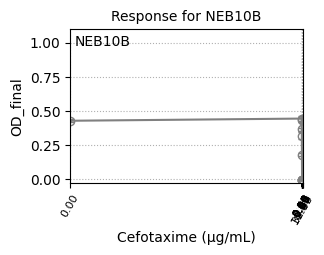

In [16]:

# Adjust the figure size as needed
fig, ax = plt.subplots(figsize=(3, 2))
plategig.static.plot_dose_response_curve_errorbar(df_analysis, 'NEB10B', 'Cefotaxime', strain_colors={'P1':'black'}, ax=ax)

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

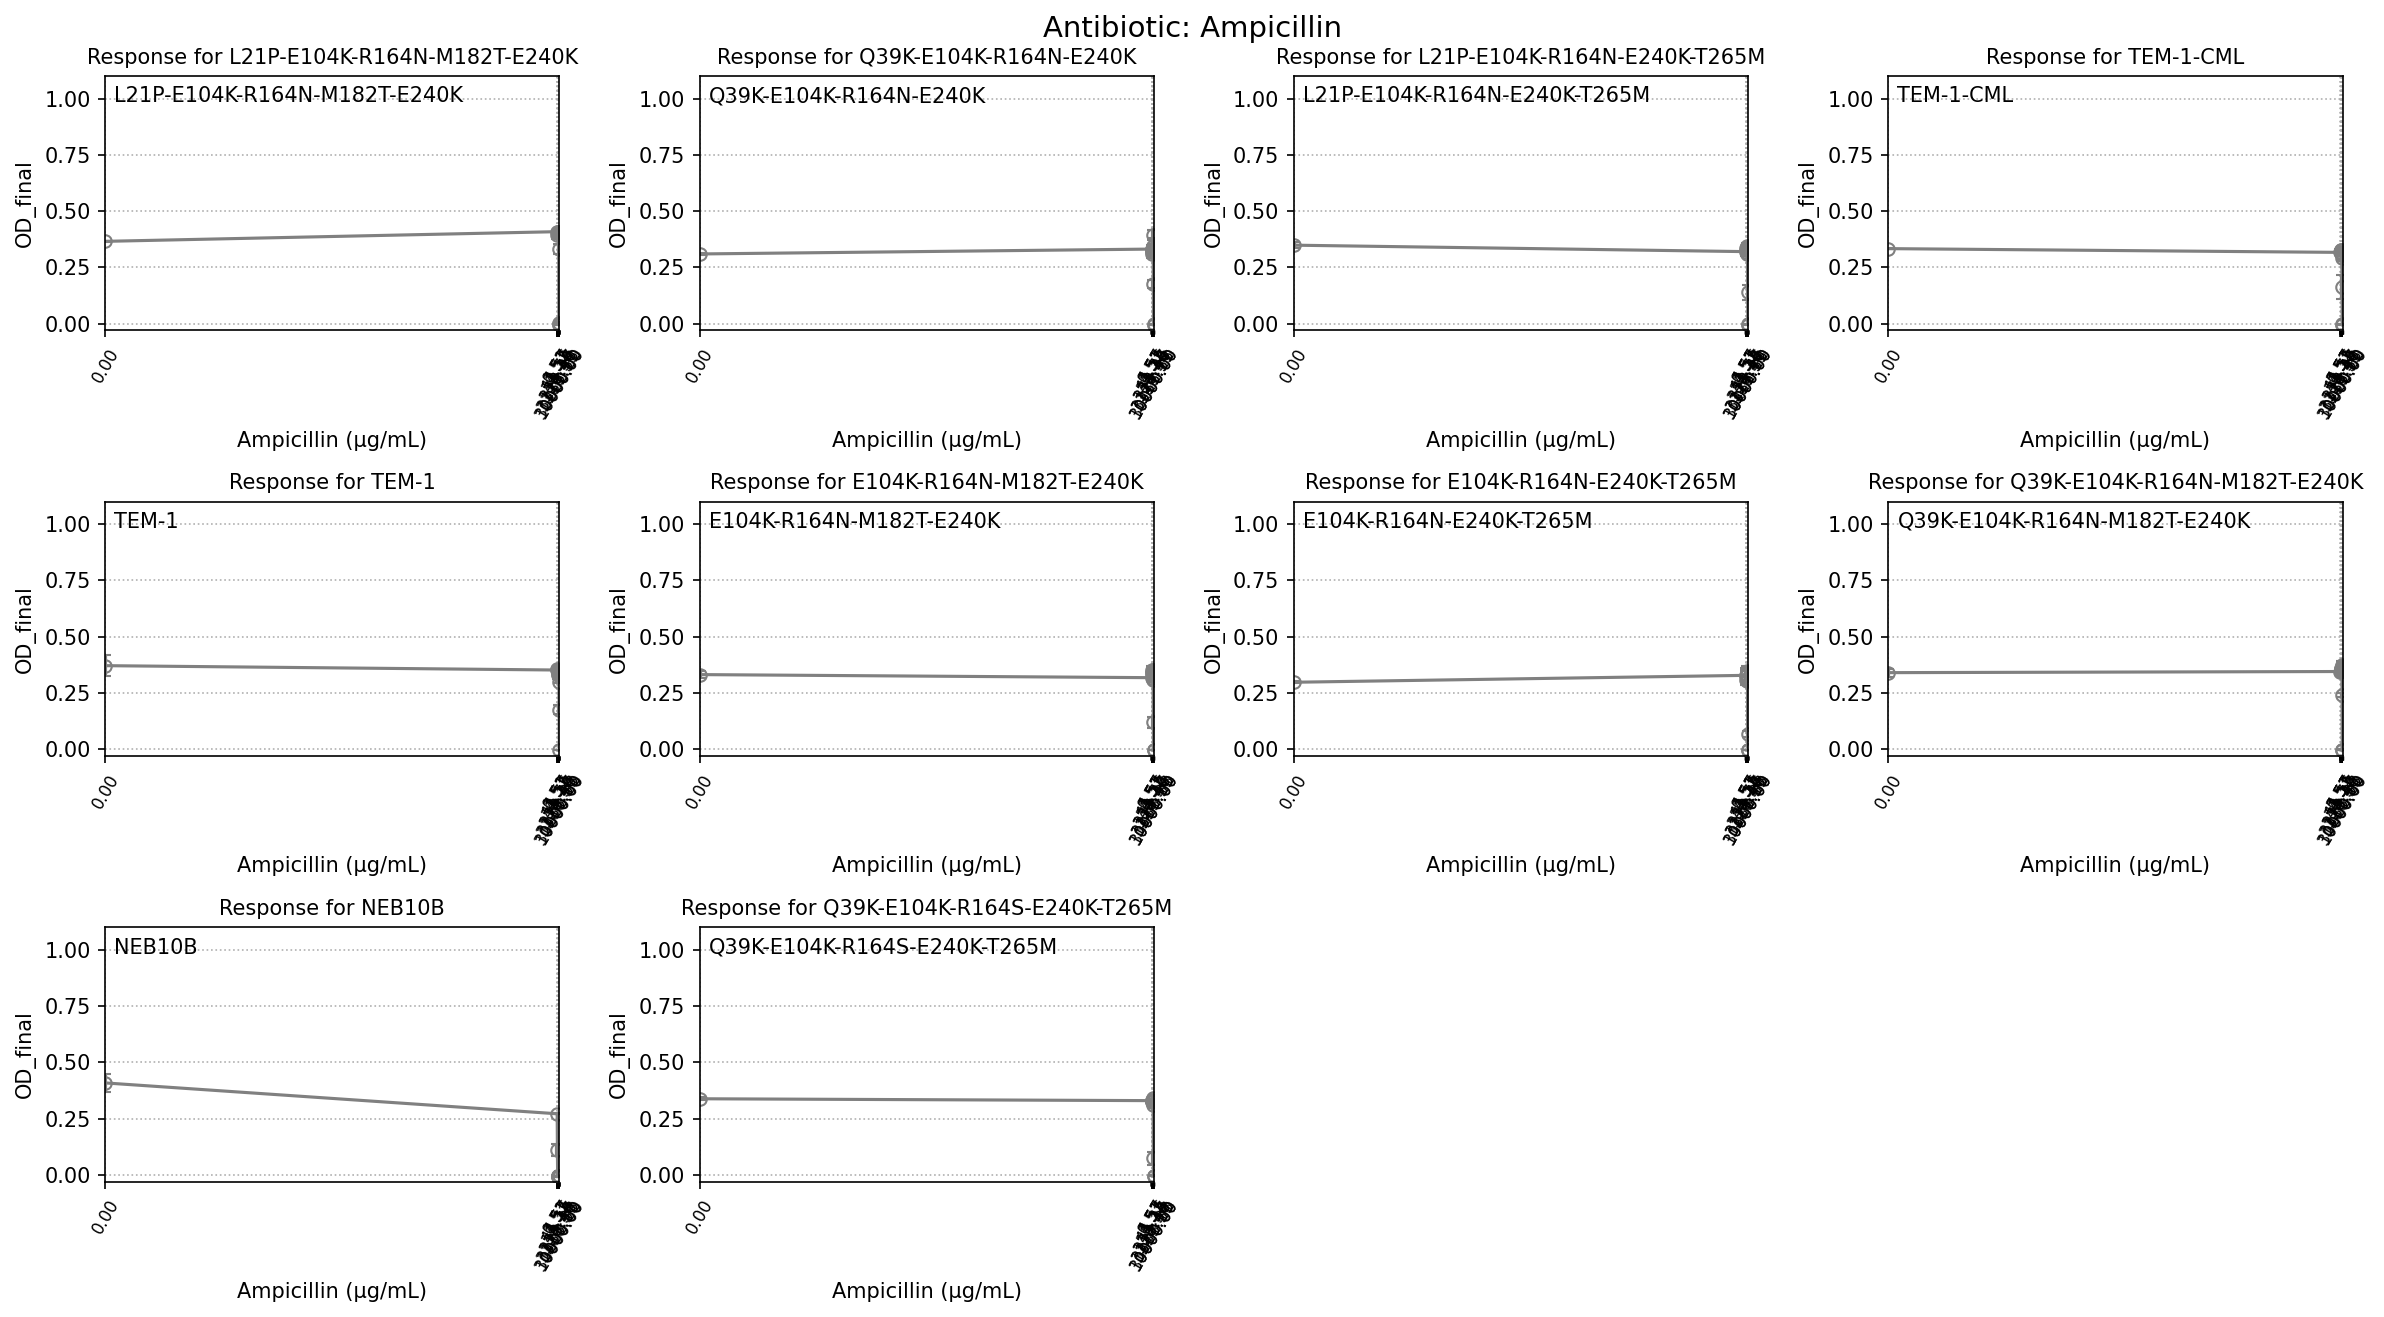

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

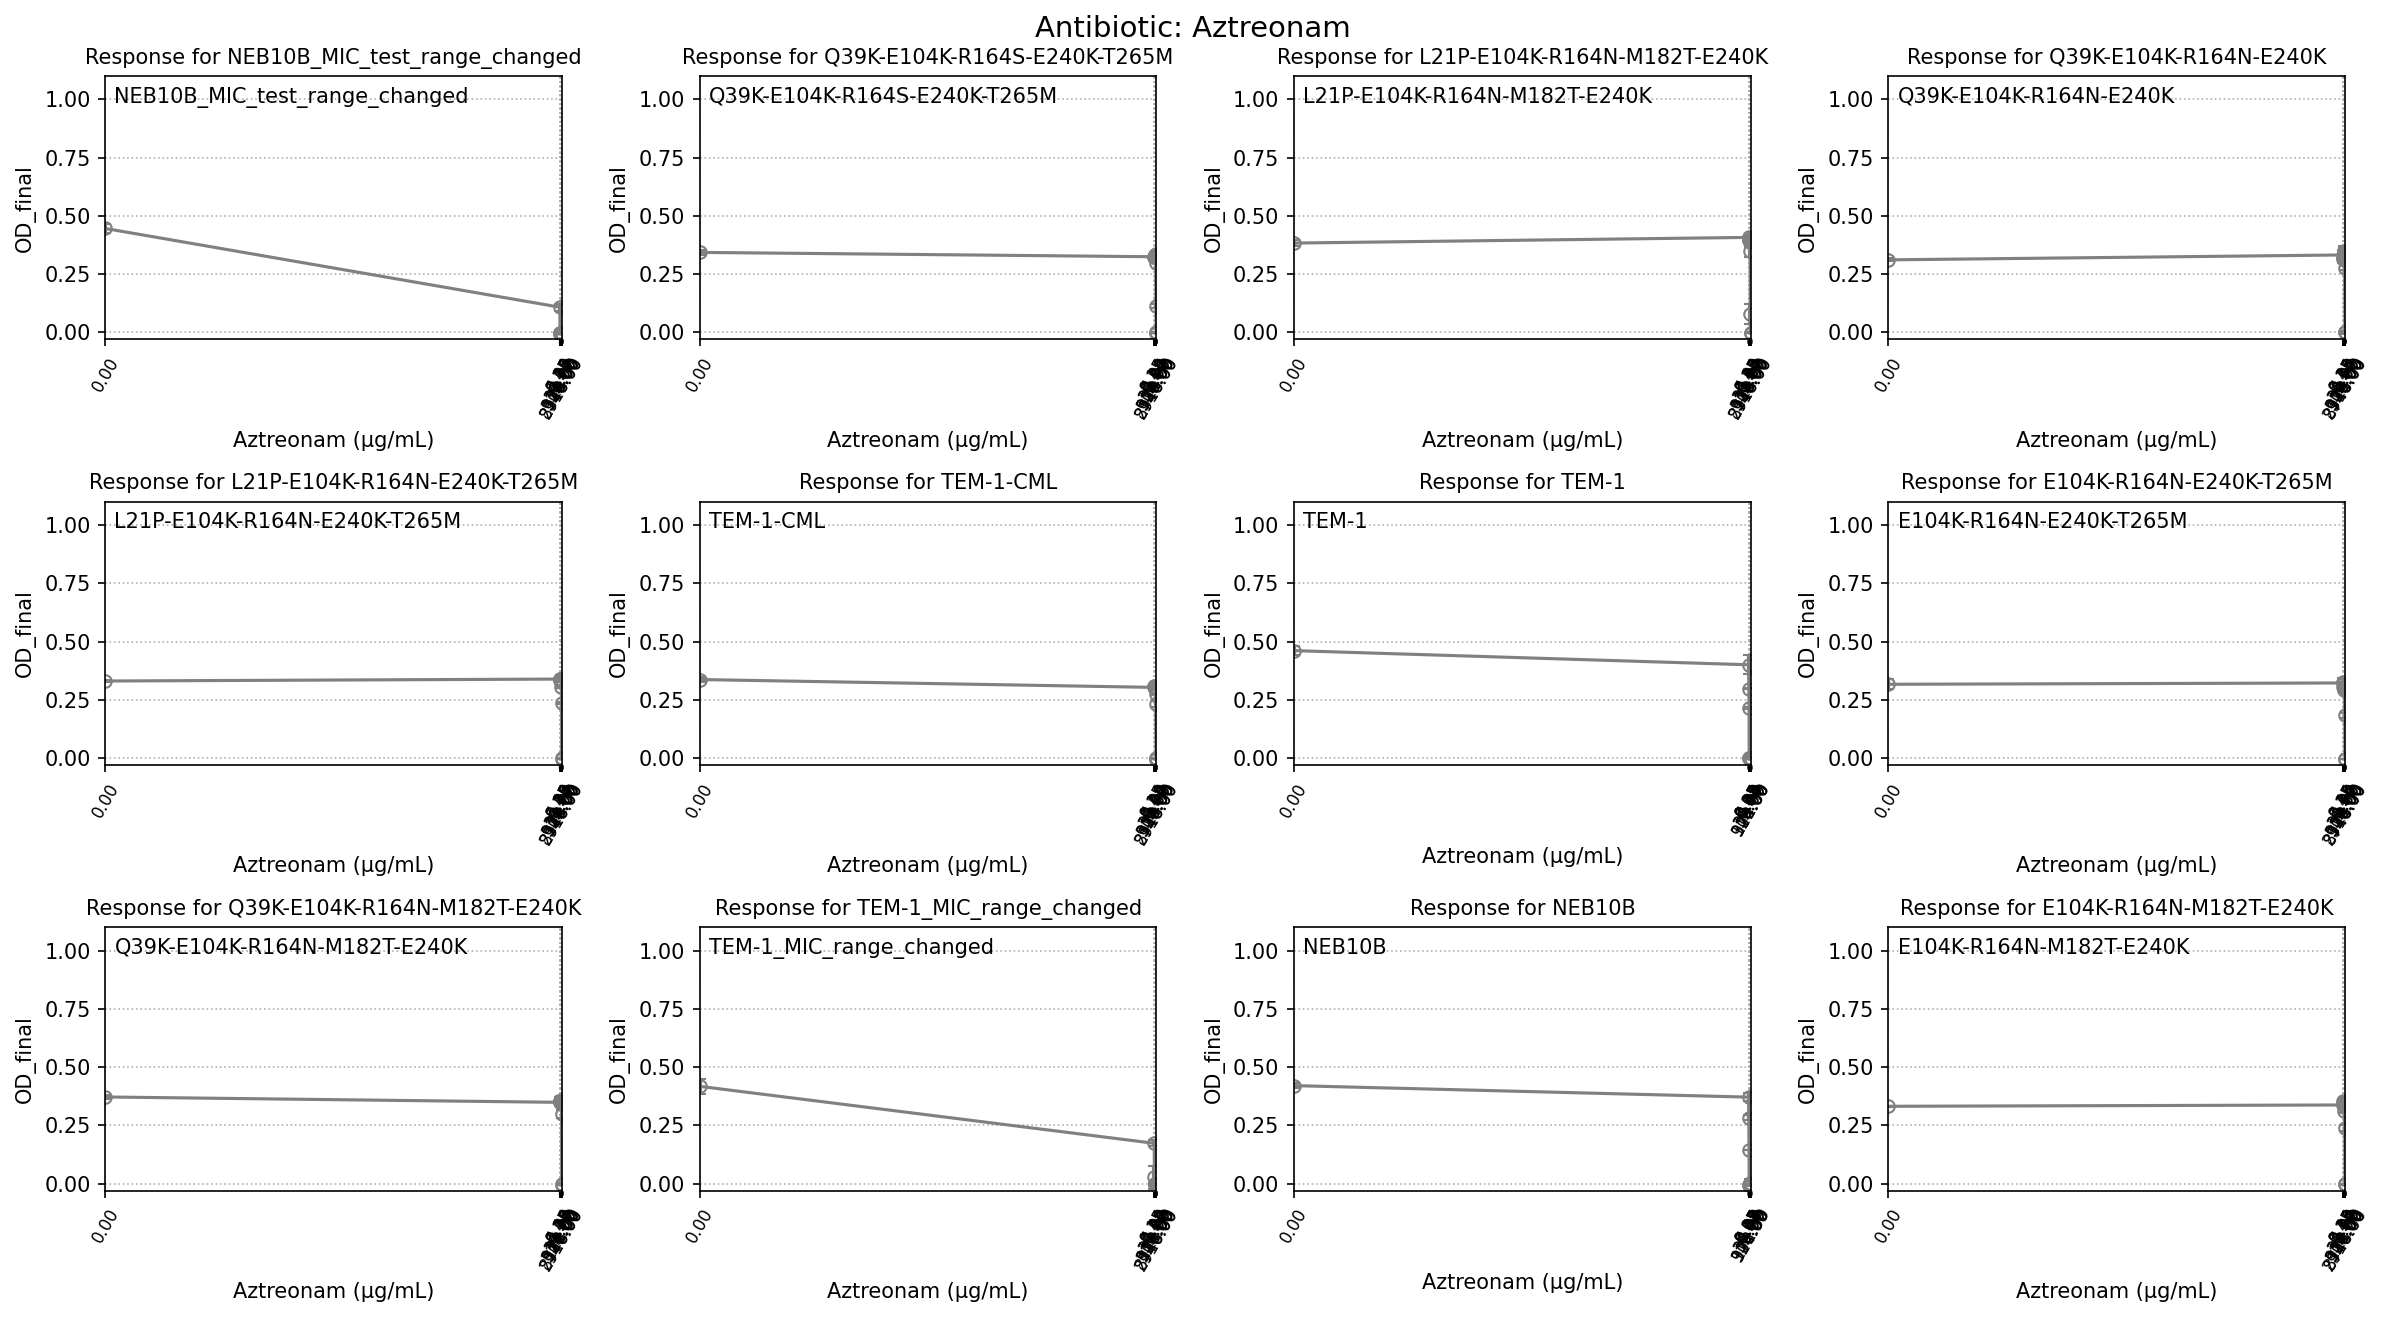

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

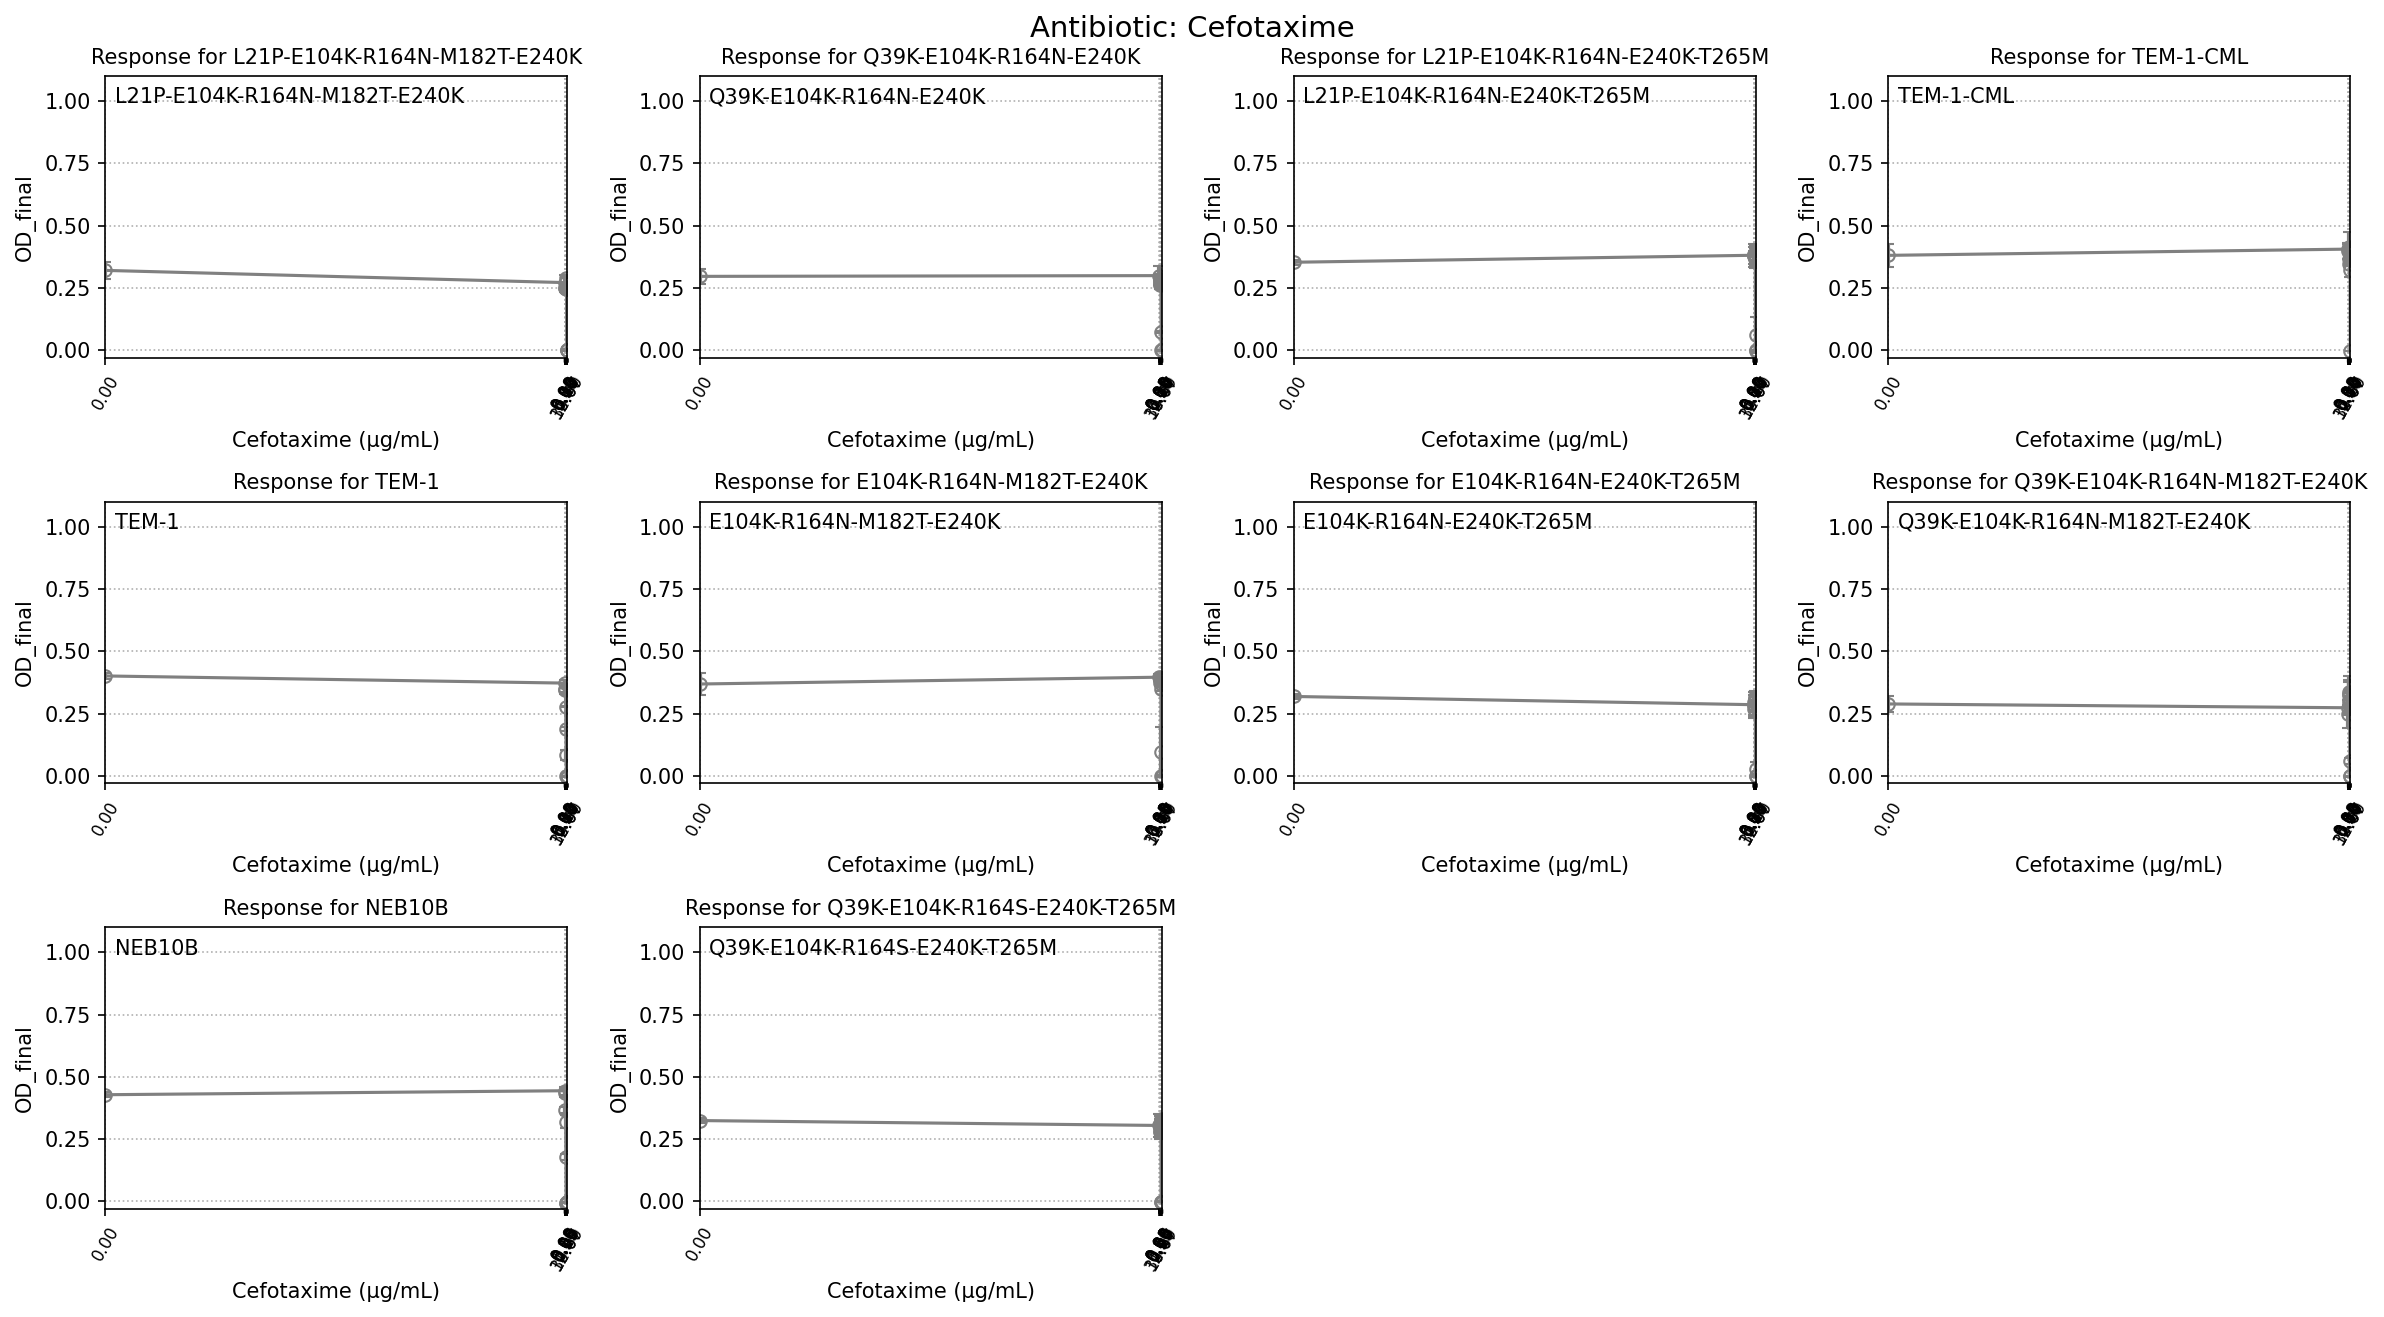

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

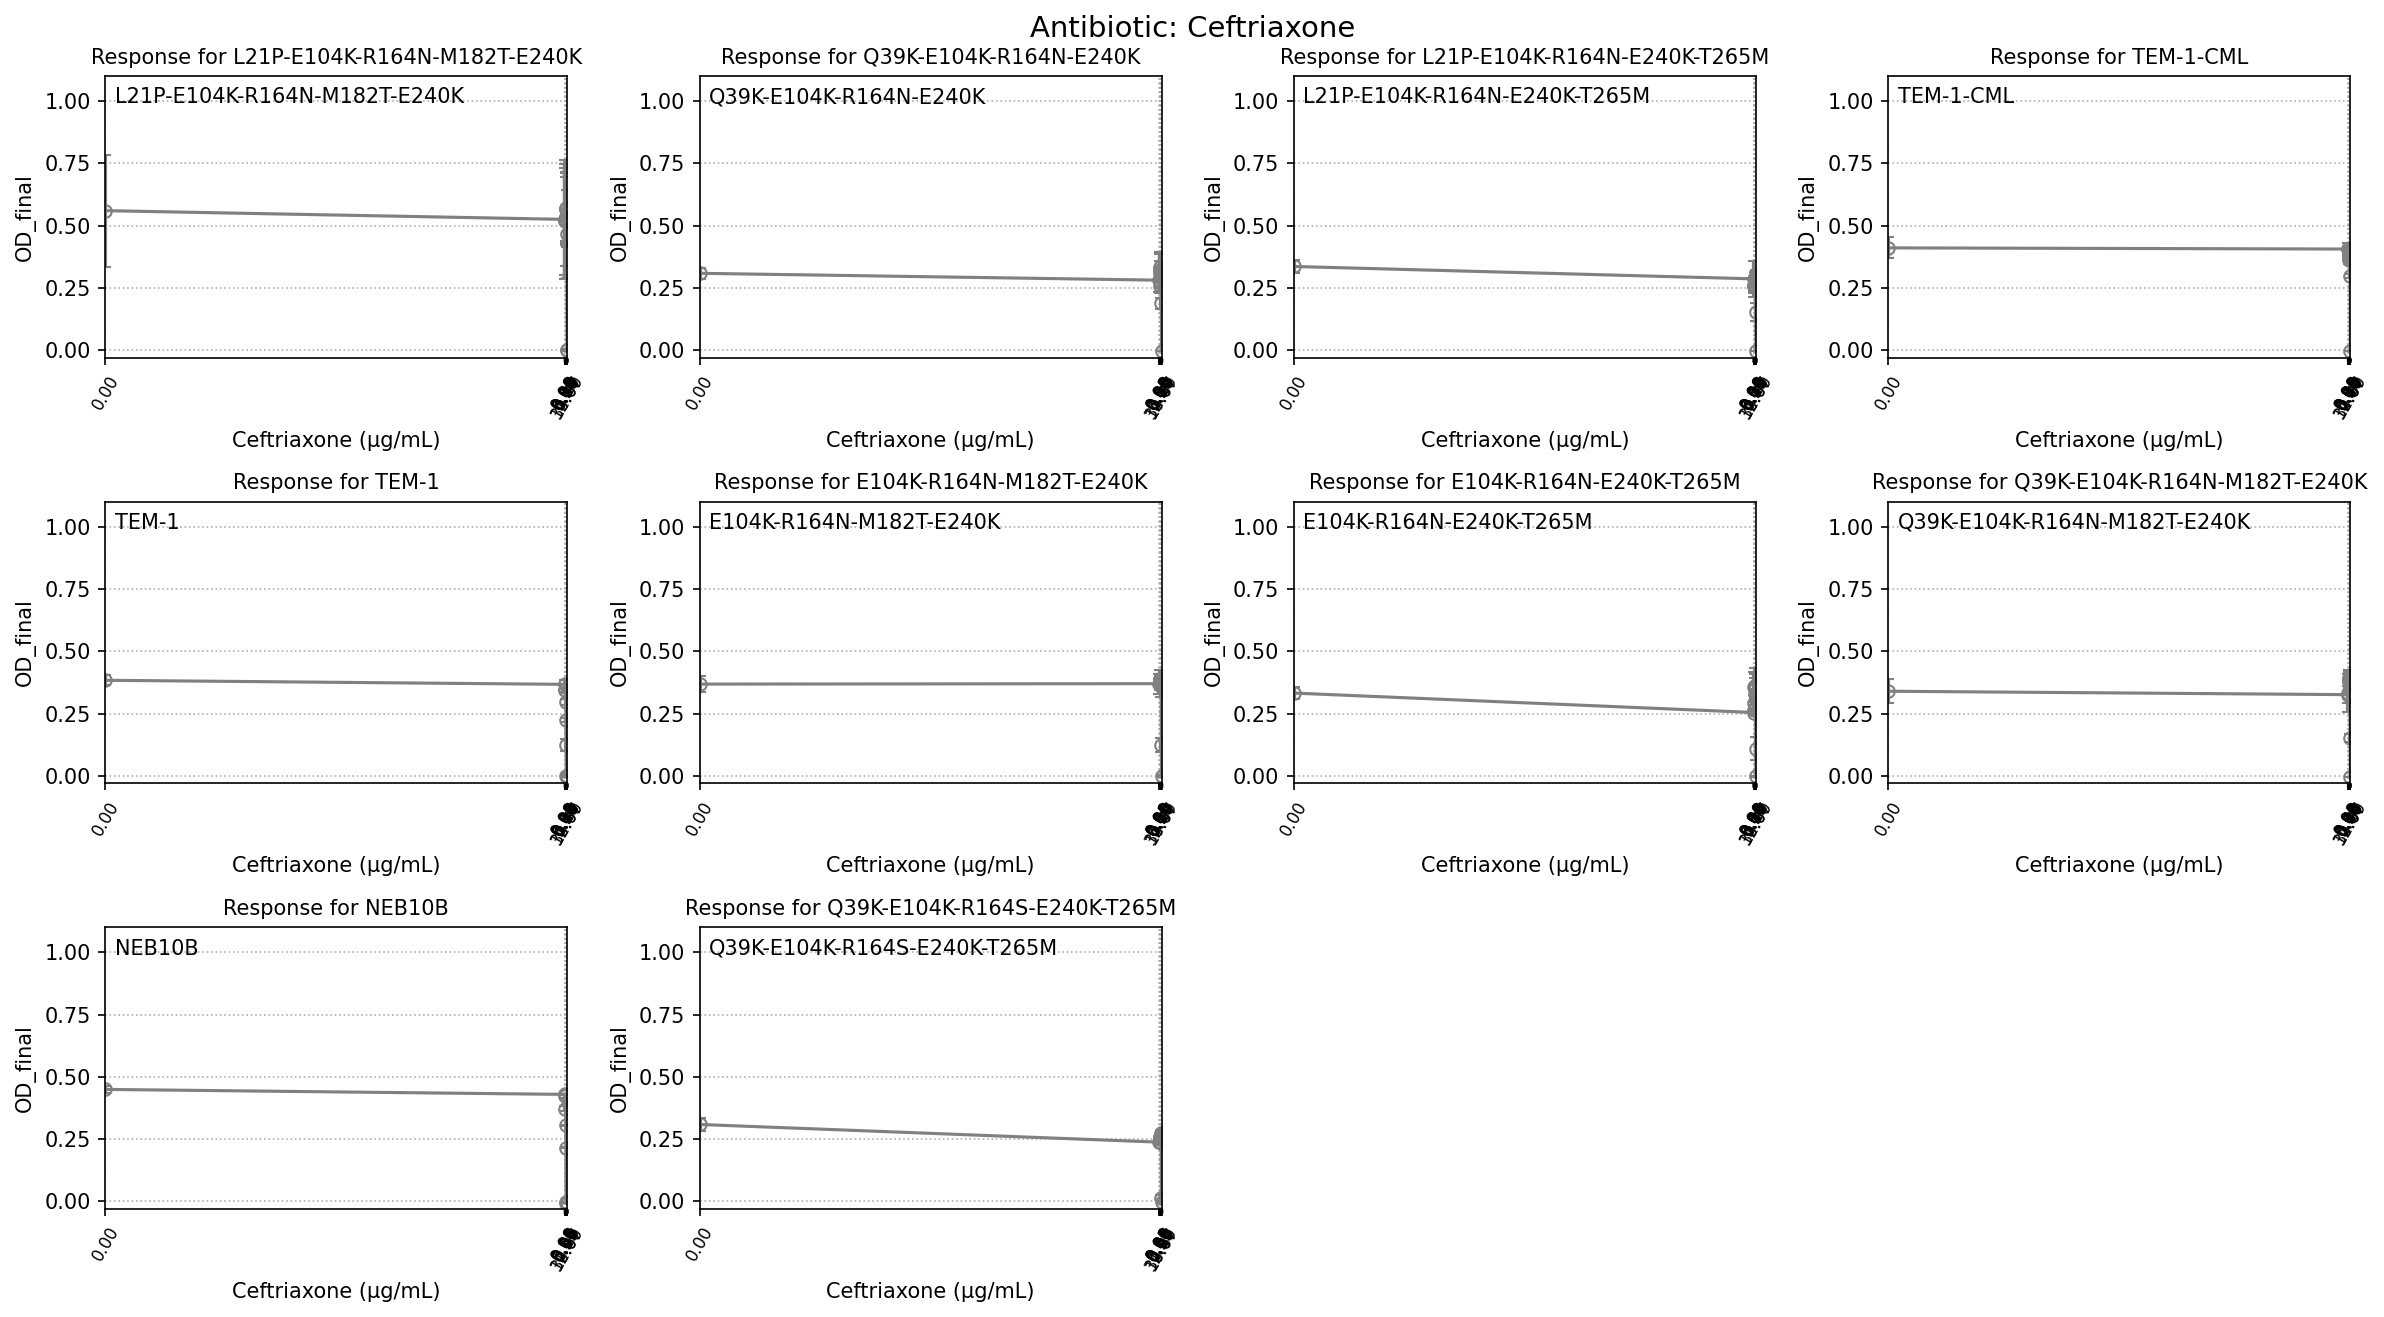

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

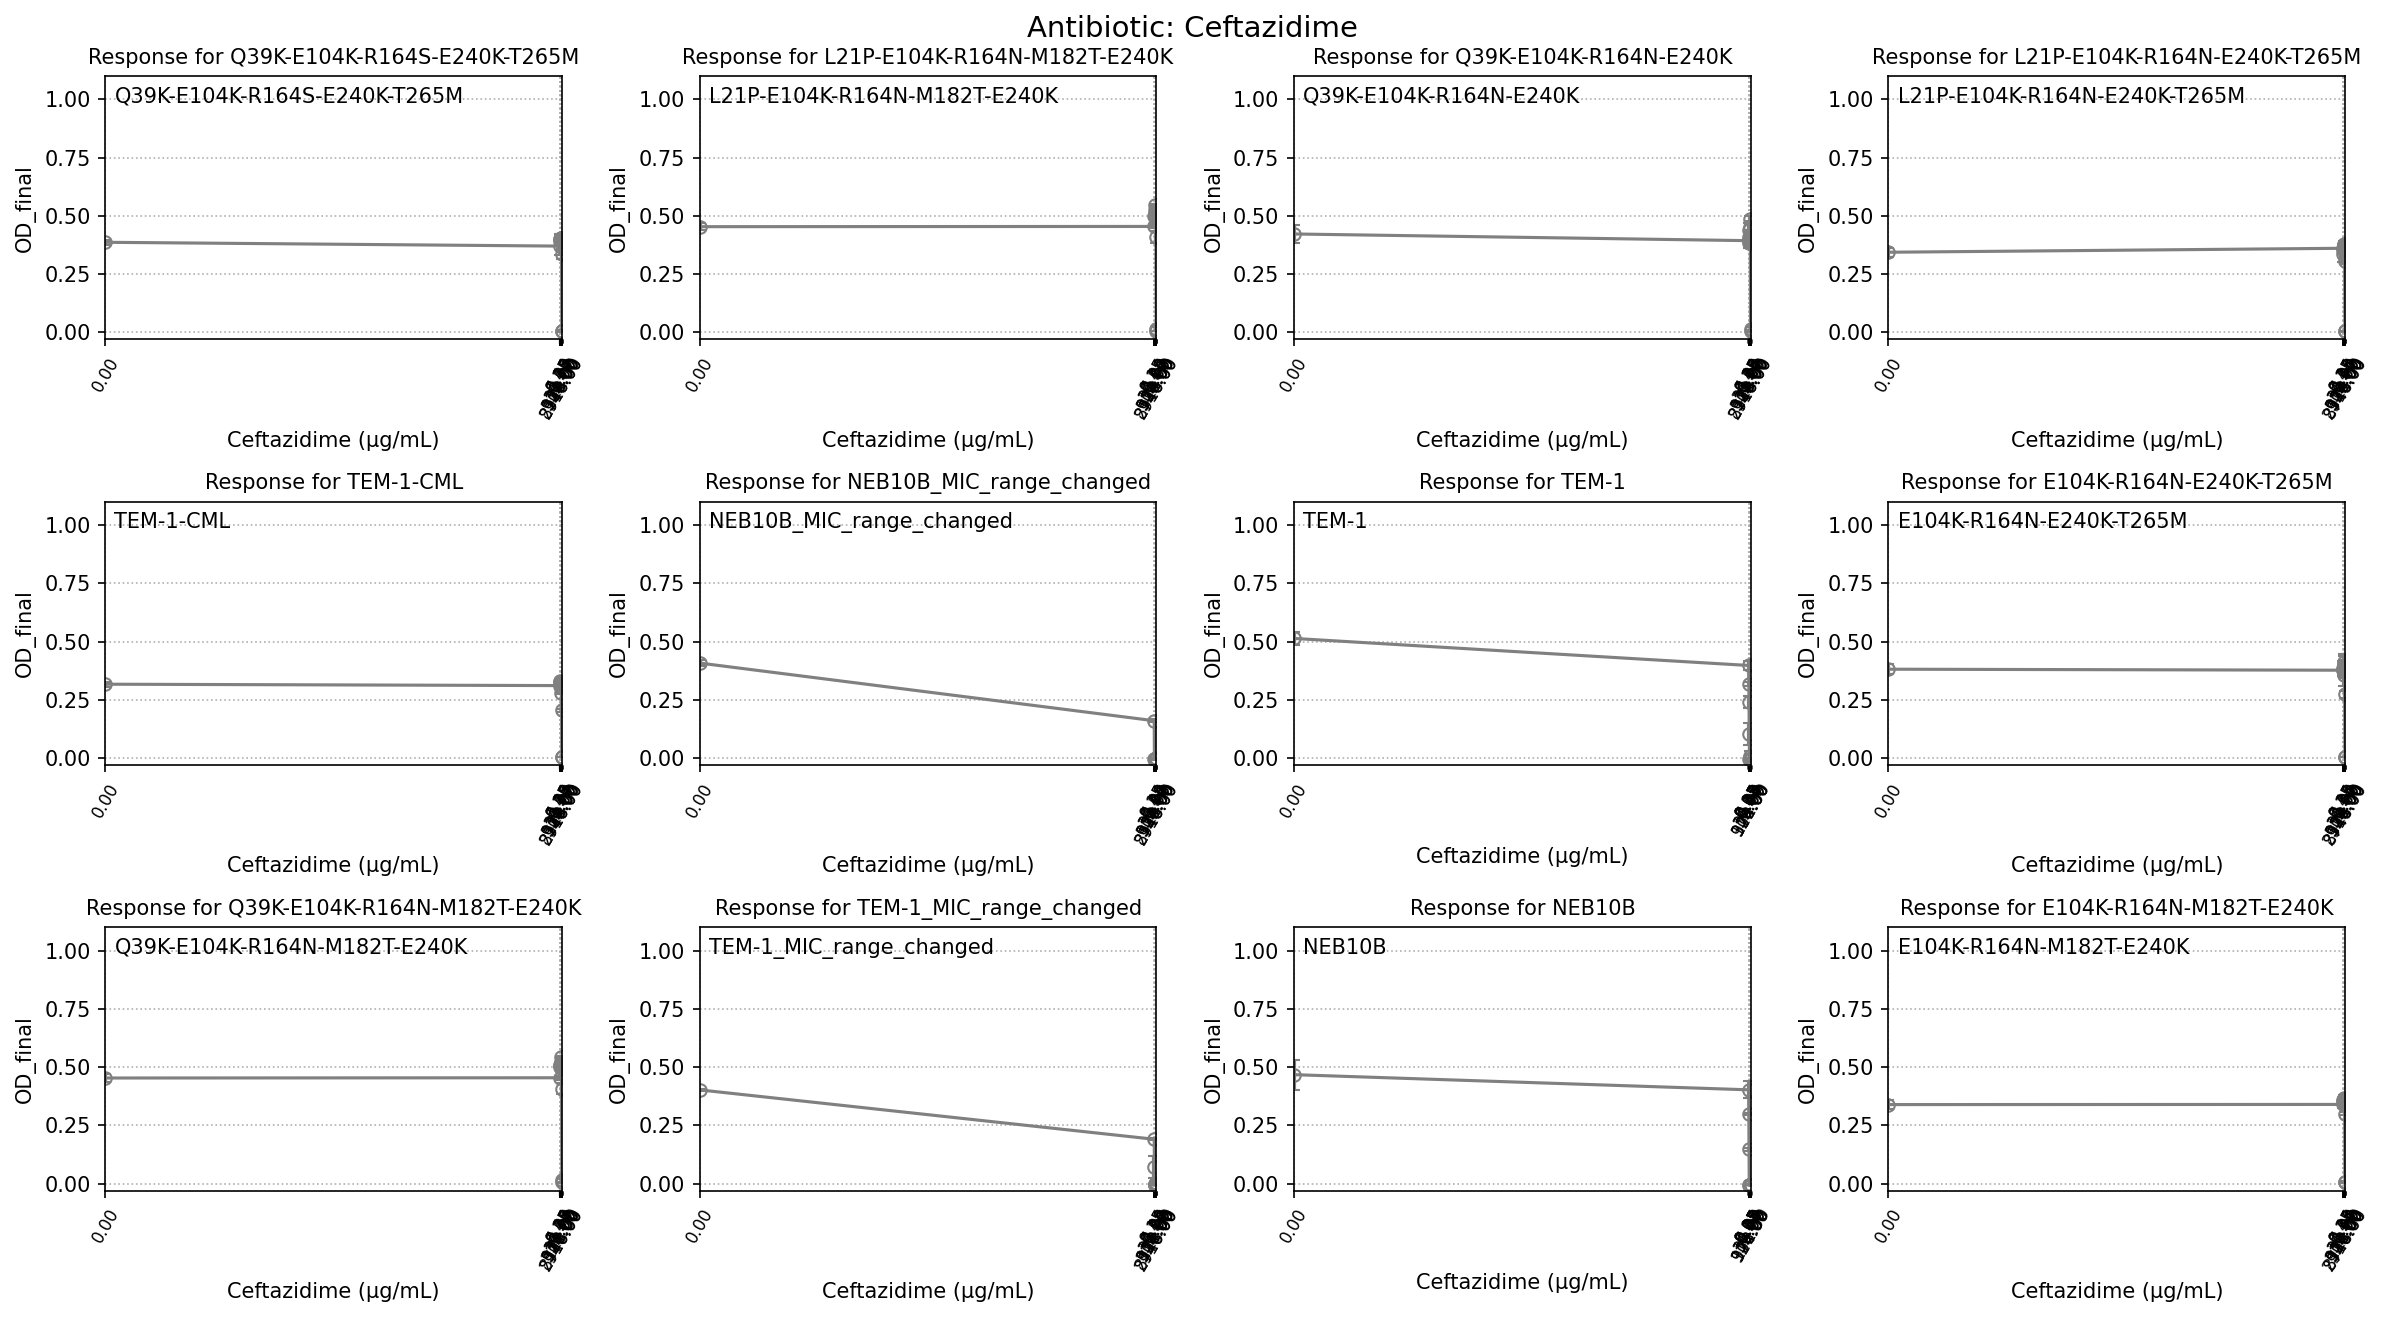

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

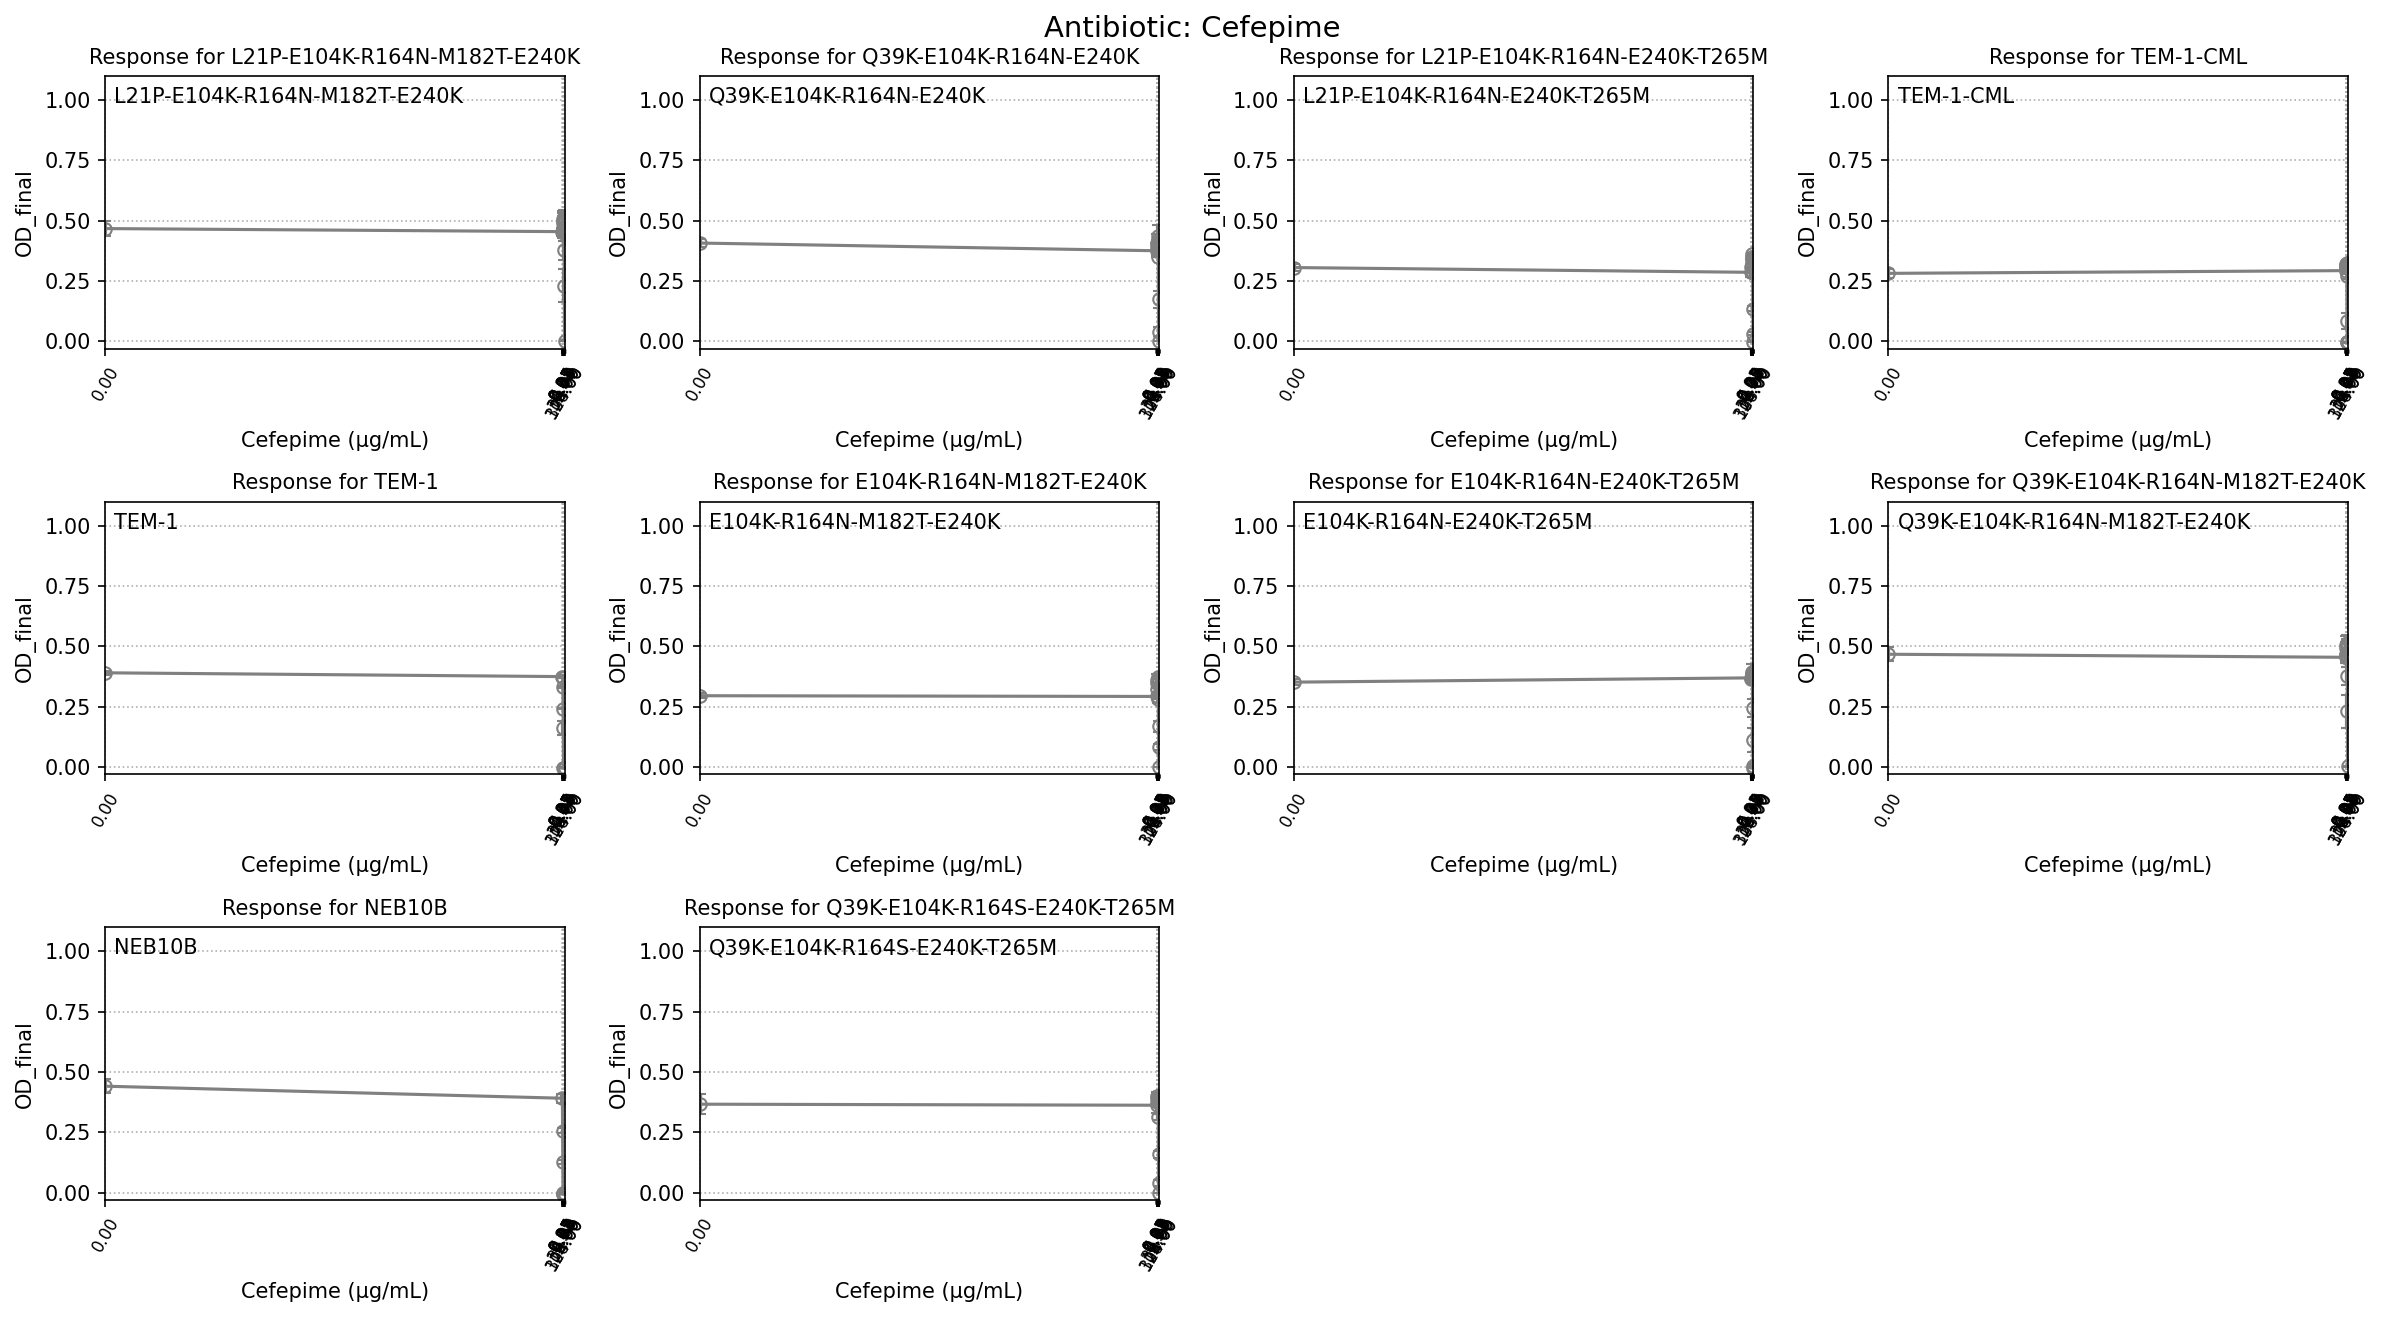

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

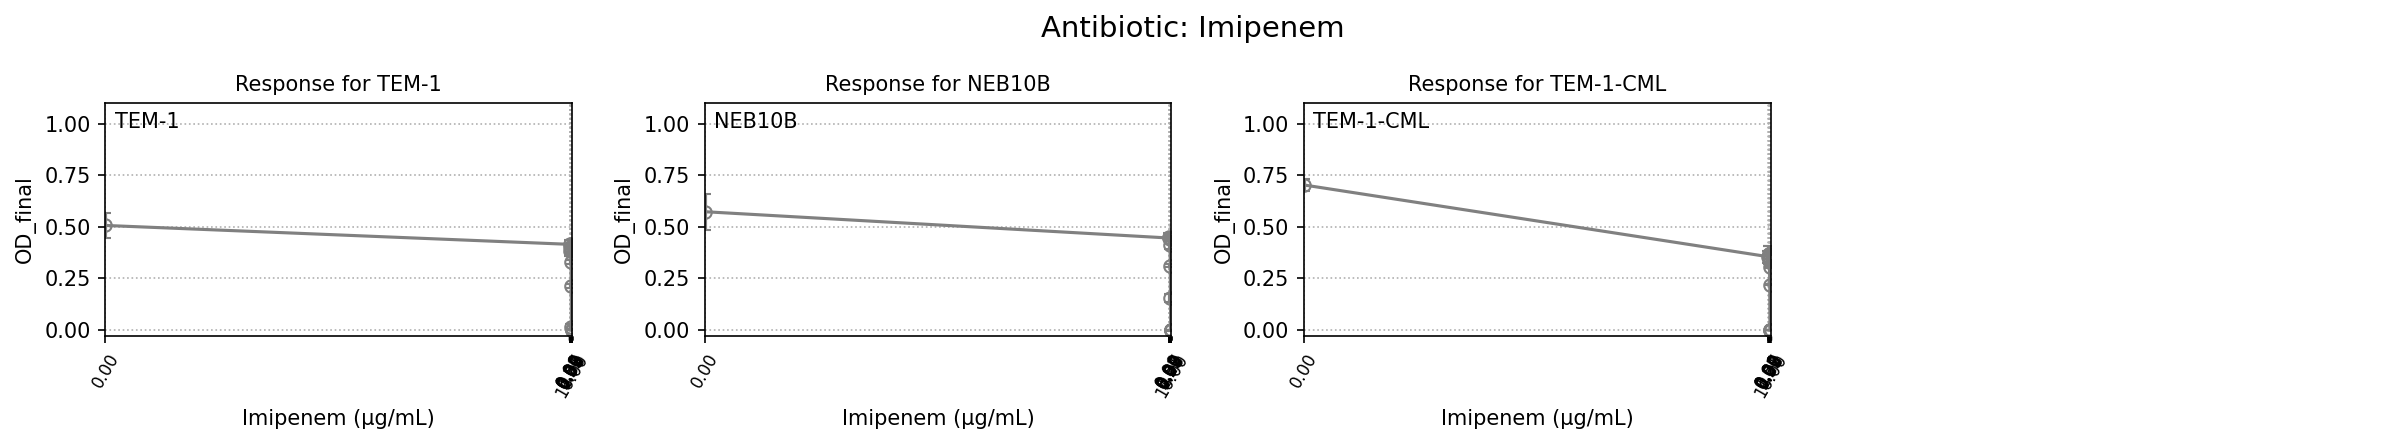

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)


/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

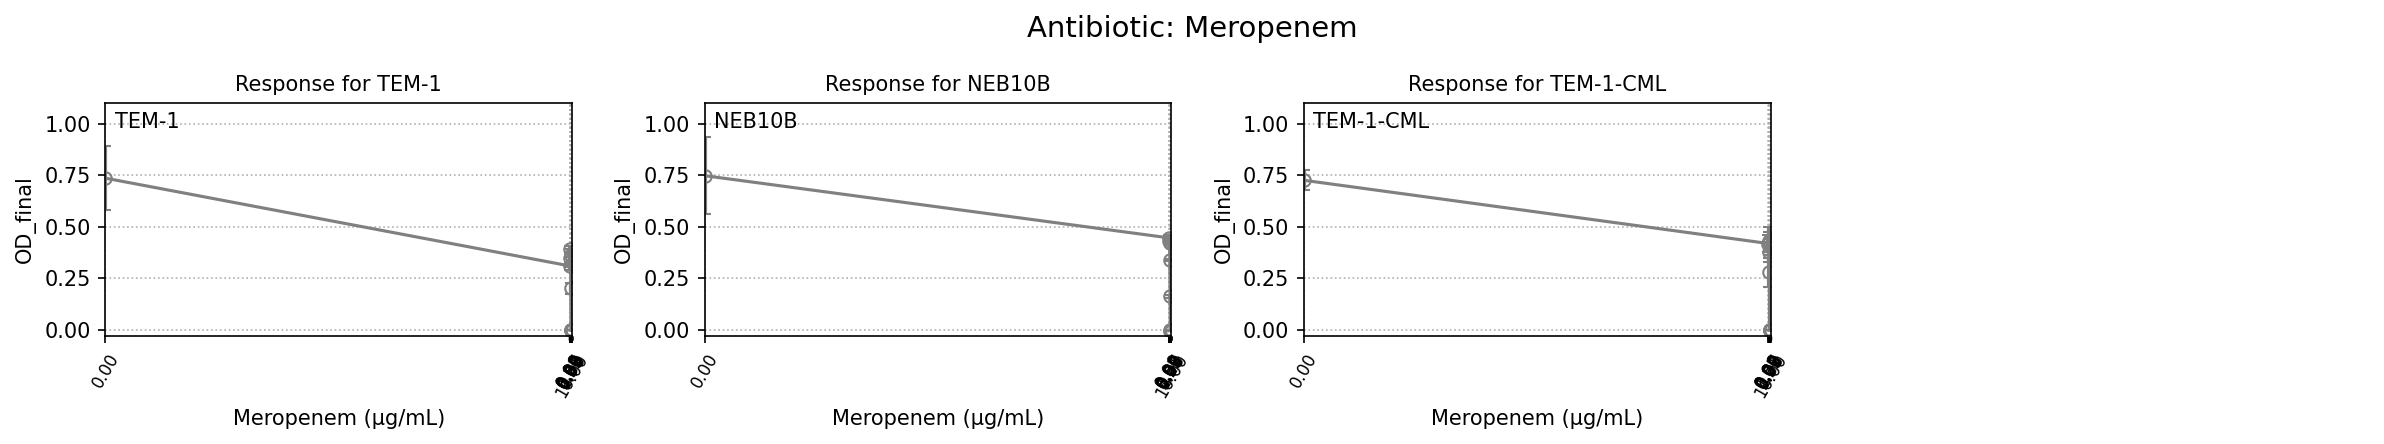

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)
/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/

/Users/wak/Documents/Toprak Lab/Gaszek-Yildiz-Meng (2026)/Gaszek_Yildiz_Meng_2025/si_figures/s02_mic/plategig/plategig.py:432: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stats['Dose'].replace(0, min_nonzero_dose / 2, inplace=True)


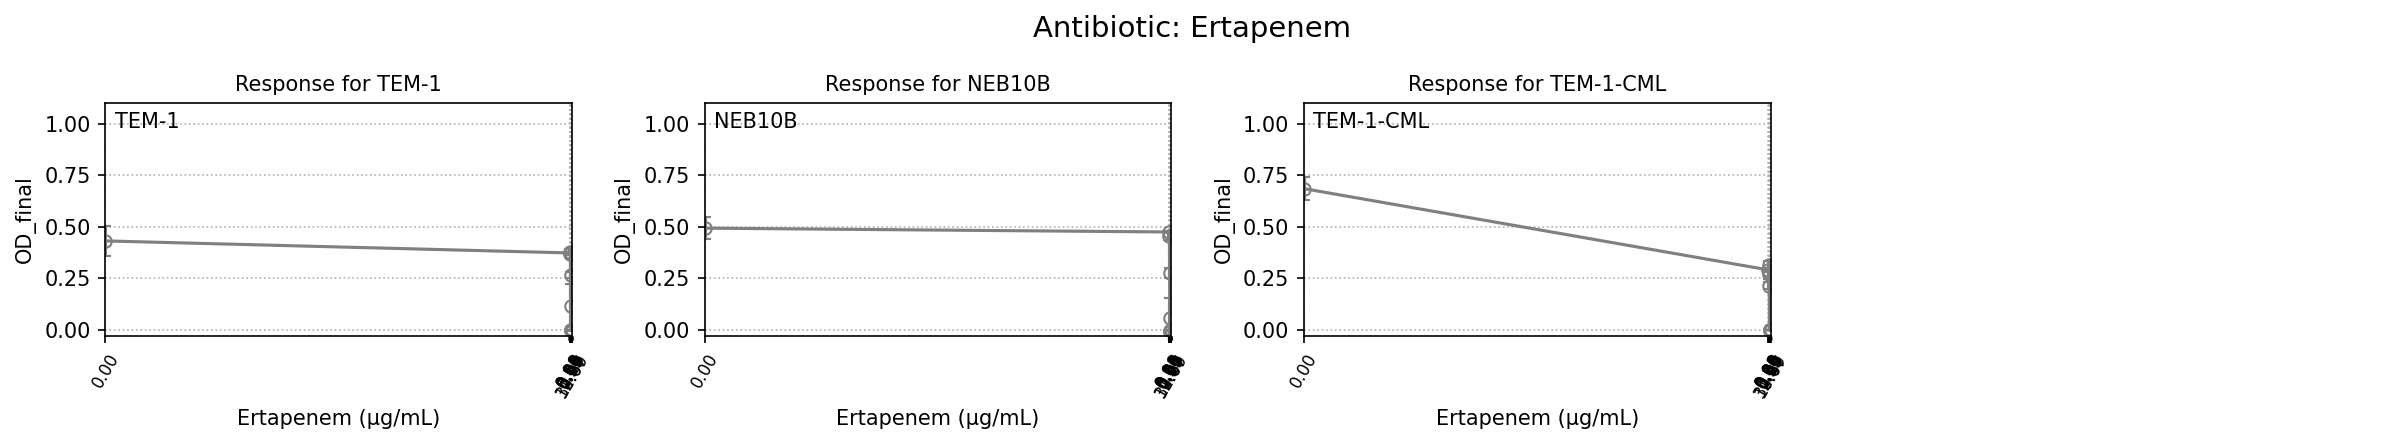

In [17]:
# Plot all dose-response curves in the df_analysis tables (might take too long)
for drug in antibiotics:
    if not pd.isna(drug):
        plategig.static.plot_od_final_for_selected_antibiotic(
            df_analysis,
            plategig.static.plot_dose_response_curve_errorbar,
            drug,
            strain_colors={})

In [18]:
valid_combinations = plategig.static.prep_valid_combinations(
    df_analysis,
    multiplex=['Strain', 'Antibiotic'],
    ic50_threshold=0.5,
    mic_threshold=0.05)
valid_combinations

,Strain,Antibiotic
0,NEB10B,Ampicillin
1,NEB10B_MIC_test_range_changed,Aztreonam
2,TEM-1,Ampicillin
3,TEM-1_MIC_range_changed,Aztreonam
4,TEM-1-CML,Ampicillin
...,...,...
68,TEM-1-CML,Imipenem
69,TEM-1-CML,Meropenem
70,NEB10B,Ertapenem
71,TEM-1,Ertapenem


In [19]:
growth_features = plategig.static.apply_phenotyper(df_analysis, valid_combinations)
growth_features = plategig.static.cap_growth_features_within_experiment_range(growth_features)
growth_features

,Strain,Antibiotic,Status,IC50,MIC,IC50_ci_lower,IC50_ci_upper,MIC_ci_lower,MIC_ci_upper,max_growth,max_growth_ci_lower,max_growth_ci_upper,hill_coeff,ic50_threshold,mic_threshold,x_fit,y_fit,ic50_bootstrap,insufficient_drug
0,NEB10B,Ampicillin,PASS,0.503421,3.675764,0.374075,0.607732,2.661274,5.120995,0.685650,0.414901,0.714349,1.481040,0.342825,0.034282,"[0.254026315, 0.2604830862989088, 0.2671039740...","[0.5029993653404274, 0.497975191328757, 0.4928...","[0.5833876878572634, 0.5513736222095437, 0.526...",False
1,NEB10B_MIC_test_range_changed,Aztreonam,FAIL - Insufficient dose range,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],[],False
2,TEM-1,Ampicillin,PASS,10315.348536,79984.203165,9399.002162,11740.554110,54390.356727,130067.379548,0.349980,0.343889,0.357527,1.437577,0.174990,0.017499,"[0.254026315, 0.284665464449994, 0.31900012662...","[0.3499803919982956, 0.34998037724394254, 0.34...","[10374.615219853402, 10333.883738641296, 9544....",False
3,TEM-1_MIC_range_changed,Aztreonam,PASS,0.201274,0.577103,0.133517,0.281357,0.216076,1.119538,0.421442,0.356043,1.983660,2.795294,0.210721,0.021072,"[0.07407407407407407, 0.0785281329553726, 0.08...","[0.3971500589880514, 0.3931325055429763, 0.388...","[0.17436209573986317, 0.17360012007182277, 0.2...",False
4,TEM-1-CML,Ampicillin,PASS,3436.500584,15511.684271,2692.574286,4810.278505,8068.431198,41682.558666,0.319722,0.316221,0.323144,1.953660,0.159861,0.015986,"[0.254026315, 0.28152396805788277, 0.311998166...","[0.3197217276559986, 0.3197217270522915, 0.319...","[3462.4336217871155, 3597.9431676298846, 4330....",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,TEM-1-CML,Imipenem,PASS,0.088875,4.215437,0.070994,0.099304,2.825388,13.296128,0.459070,0.362370,1.807599,0.762952,0.229535,0.022954,"[0.00013548070246744226, 0.0001535157433880983...","[0.45583716147429487, 0.45551619631173934, 0.4...","[0.08872132820532035, 0.09199094359833933, 0.0...",False
69,TEM-1-CML,Meropenem,PASS,0.016871,0.557205,0.012070,0.022904,0.253725,1.976732,0.547881,0.434932,0.941517,0.841914,0.273941,0.027394,"[0.00015000000000000004, 0.0001679193331855493...","[0.5377933233535495, 0.5368082026327817, 0.535...","[0.021722599114566397, 0.017857640974077747, 0...",False
70,NEB10B,Ertapenem,PASS,0.006254,0.075011,0.005752,0.006919,0.053984,0.120865,0.516705,0.489965,0.565710,1.185198,0.258353,0.025835,"[0.0002709614049348845, 0.0002840841929686677,...","[0.5044847091345414, 0.5037977538058734, 0.503...","[0.0064260190092196, 0.005809817487125996, 0.0...",False
71,TEM-1,Ertapenem,PASS,0.030054,0.471448,0.026959,0.033694,0.338443,0.717982,0.405185,0.379954,0.465389,1.069613,0.202592,0.020259,"[0.0002709614049348845, 0.00029697828559114263...","[0.4025694733841558, 0.40230194688508997, 0.40...","[0.029911697263808504, 0.03207321090890073, 0....",False


In [20]:
# growth_features['group'] = growth_features['Strain'].apply(lambda x: re.split(r'[1-9]', x)[0])
# growth_features

In [21]:
strains = list(set(df_analysis['Strain'].str.lower()) - set(['media only', 'cells only', np.nan]))
print(strains)

['e104k-r164n-m182t-e240k', 'neb10b_mic_test_range_changed', 'l21p-e104k-r164n-m182t-e240k', 'tem-1-cml', 'q39k-e104k-r164n-m182t-e240k', 'neb10b', 'l21p-e104k-r164n-e240k-t265m', 'tem-1_mic_range_changed', 'tem-1', 'neb10b_mic_range_changed', 'q39k-e104k-r164s-e240k-t265m', 'q39k-e104k-r164n-e240k', 'e104k-r164n-e240k-t265m']


In [22]:
antibiotics = list(set(df_analysis['Antibiotic'].str.lower()) - set(['media only', 'cells only', np.nan]))
antibiotics

['cefotaxime',
 'imipenem',
 'cefepime',
 'ampicillin',
 'ceftazidime',
 'ceftriaxone',
 'aztreonam',
 'meropenem',
 'ertapenem']

In [23]:
strain_colors = {strain:color for strain, color in zip(strains, sns.color_palette('muted')[:len(strains)])}


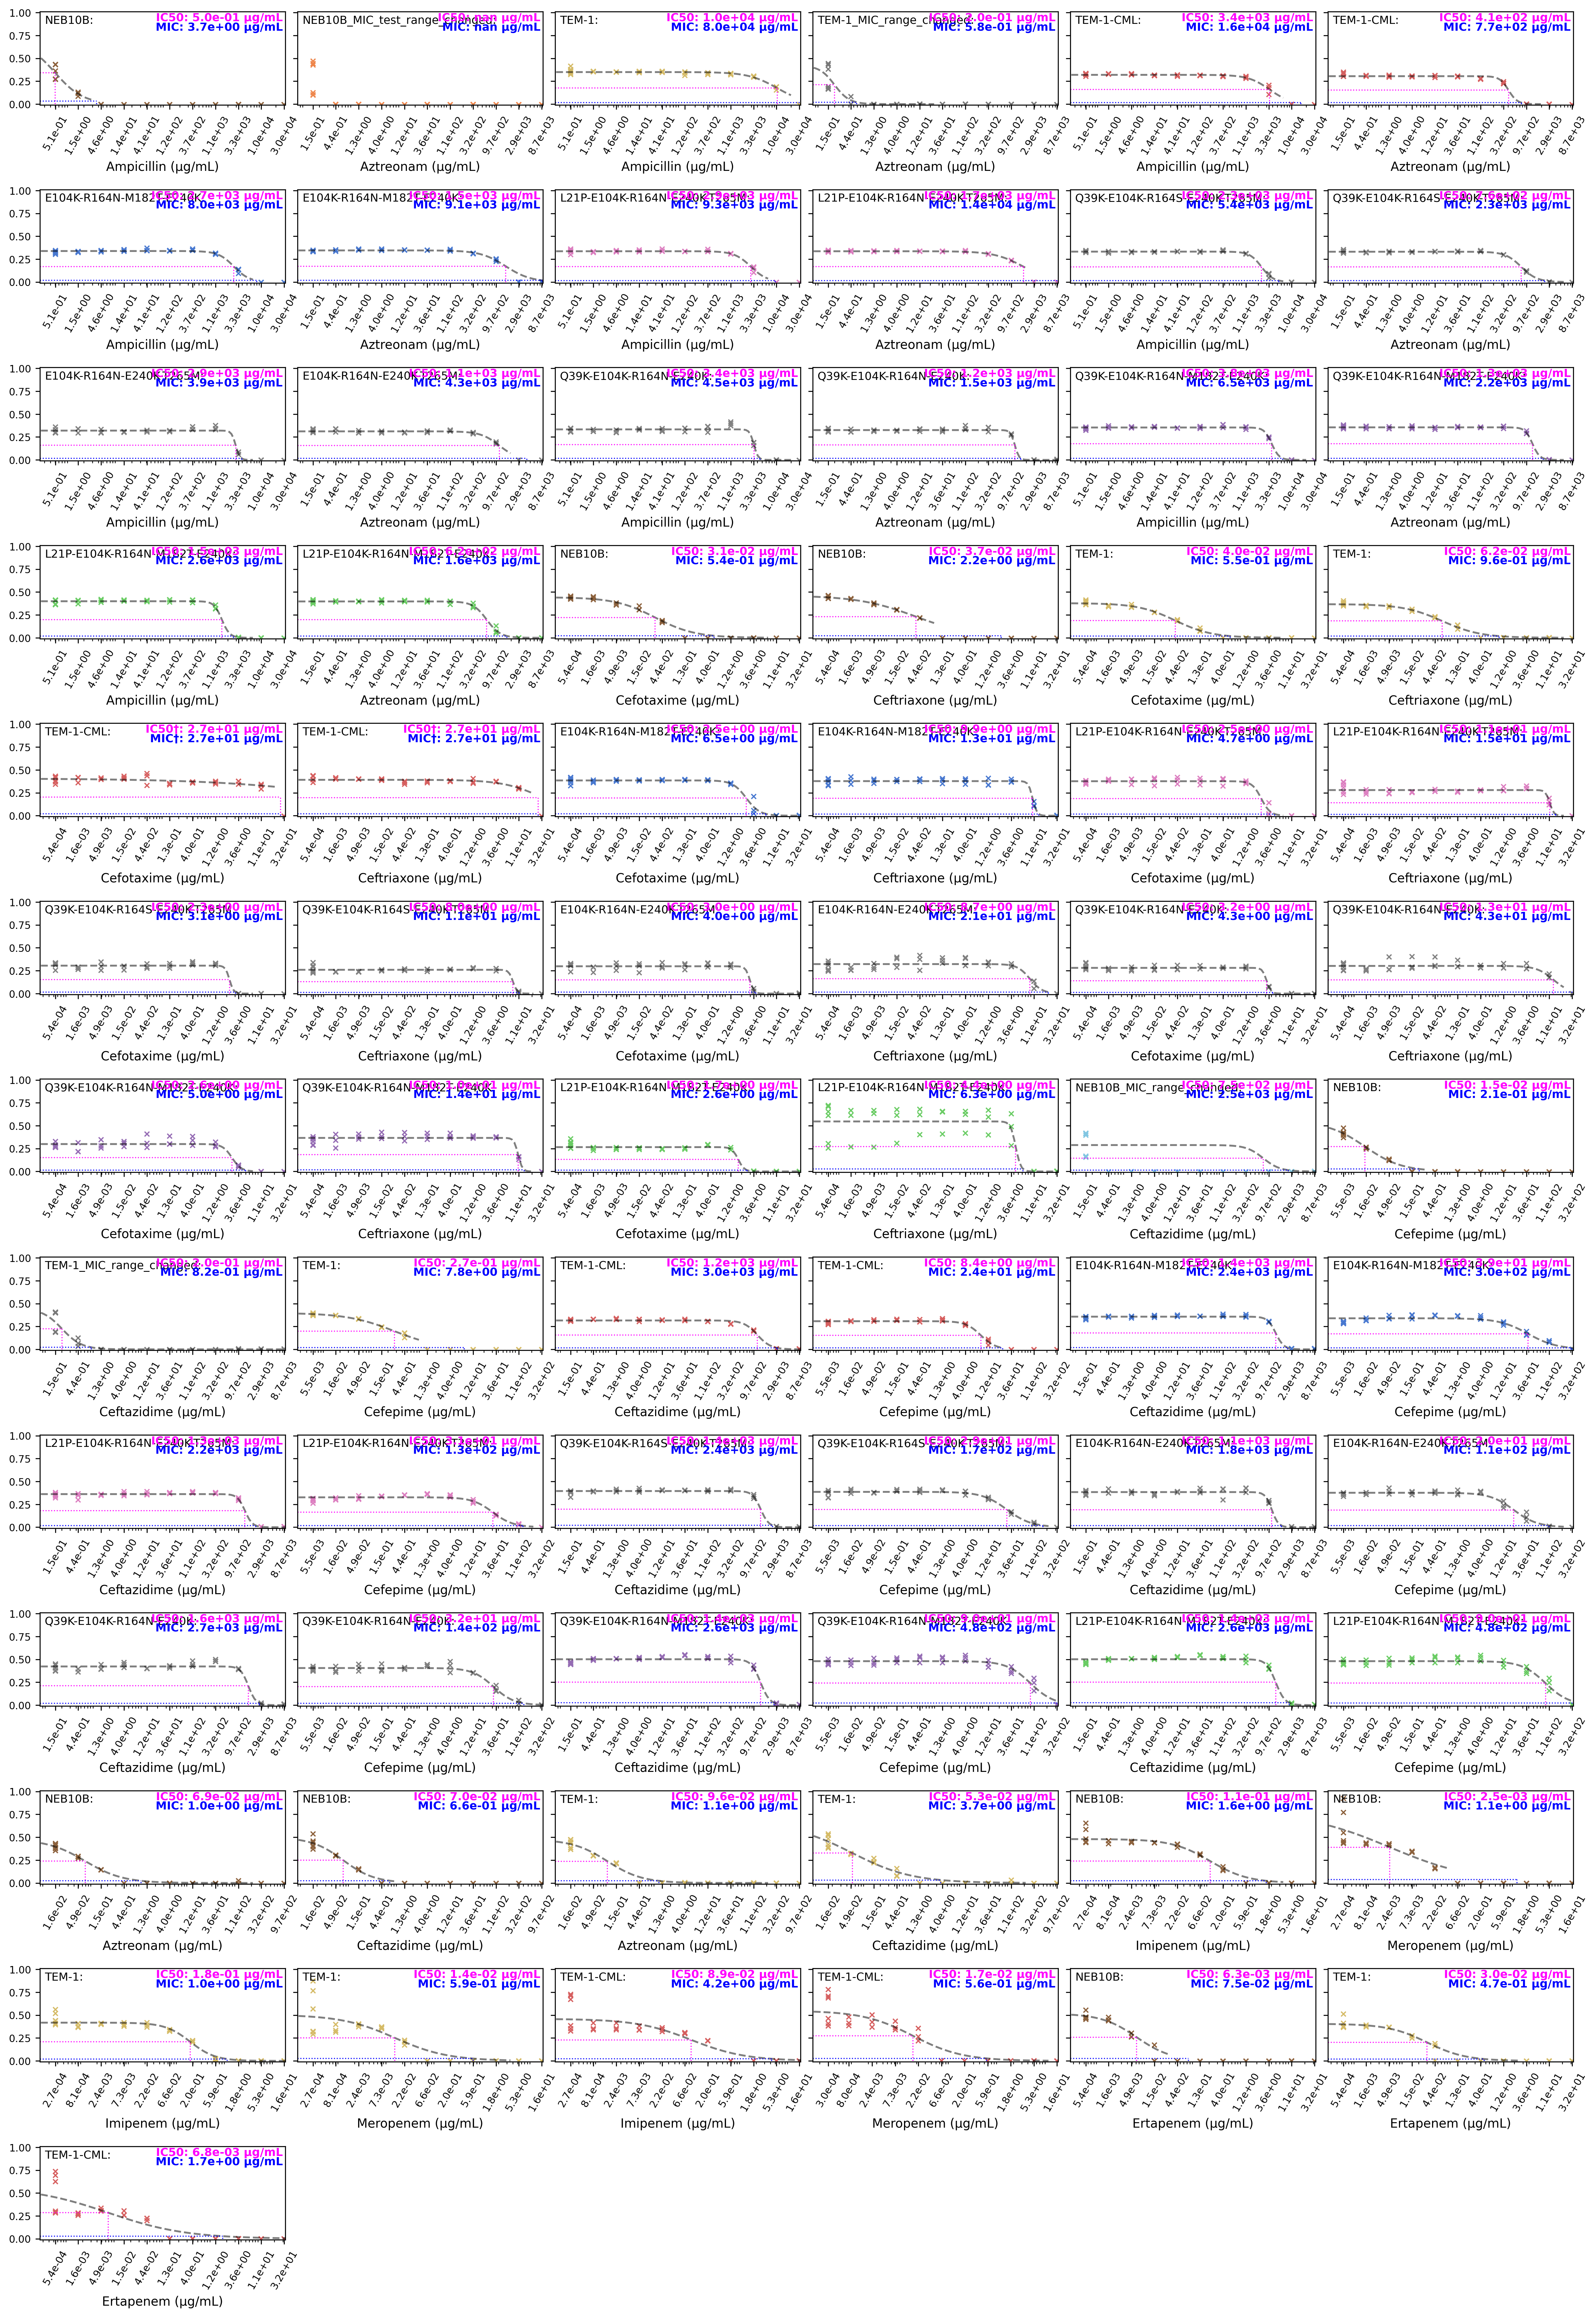

In [24]:
num_drugs = growth_features['Antibiotic'].nunique()
num_experiments = growth_features.shape[0]
num_cols = 6
num_rows = num_experiments//num_cols + (num_experiments % num_cols > 0)
# num_cols = num_experiments//num_drugs
# fig, axes = plt.subplots(num_experiments//num_replicates, num_replicates,
#                        figsize=(num_replicates*3, num_experiments*2), dpi=90)
fig, axes = plt.subplots(num_rows, num_cols,
                       figsize=(num_cols*3, num_rows*2), dpi=300)

for ix, row in growth_features.iterrows():
    plategig.static.plot_dose_response_curve_fit(df_analysis,
                                                growth_features=growth_features,
                                                strain_colors=strain_colors,
                                                strain=row['Strain'],
                                                antibiotic=row['Antibiotic'],
                                                ax=axes.flat[ix])
    
    if row['Status'] == 'FAIL':
        axes.flat[ix].text(0.5, 0.5, f'FAIL', color='red', fontsize=12, fontweight='bold',
                        ha='center', va='center', transform=axes.flat[ix].transAxes)
        # gray out the entire axes
        axes.flat[ix].set_facecolor('lightgray')
    if ix % num_cols != 0:
        axes.flat[ix].set_yticklabels([])
# Hide the rest of the axes
for ix in range(num_experiments, num_cols*num_rows):
    axes.flat[ix].axis('off')
    
fig.tight_layout()
# set empty space between subplots
fig.subplots_adjust(wspace=0.05)
fig.savefig(PROJECT_PATH / PROJECT_ID / 'figures' / f'IC50 fits.png', dpi=300, bbox_inches='tight')

In [25]:
unique_columns = growth_features.columns.unique()
print(unique_columns)

Index(['Strain', 'Antibiotic', 'Status', 'IC50', 'MIC', 'IC50_ci_lower',
       'IC50_ci_upper', 'MIC_ci_lower', 'MIC_ci_upper', 'max_growth',
       'max_growth_ci_lower', 'max_growth_ci_upper', 'hill_coeff',
       'ic50_threshold', 'mic_threshold', 'x_fit', 'y_fit', 'ic50_bootstrap',
       'insufficient_drug'],
      dtype='str')


In [26]:
#### Graphes the IC50 values for each with a confindence interval
    ### looks like it pulls growth_features

final_chart = alt.vconcat()
for drug in sorted(growth_features['Antibiotic'].unique()):
    select_cols = ['Strain','Antibiotic','Status','IC50','IC50_ci_lower','IC50_ci_upper', 'insufficient_drug']
    filtered_growth_features = growth_features[select_cols]
    filtered_growth_features = filtered_growth_features.query(f'Antibiotic == "{drug}" & Status == "PASS"')
    filtered_growth_features['StrainGroup'] = filtered_growth_features['Strain']#.str.extract(r'(\D+)')

    base = alt.Chart(filtered_growth_features).encode(
        x=alt.X('Strain', axis=alt.Axis(labelAngle=-45, labelLimit=0)),
    ).properties(width=700, height=300)

    ic50 = base.encode(
        y=alt.Y('IC50:Q', scale=alt.Scale(type="log")),
        color=alt.Color("StrainGroup:N")
    ).mark_point(filled=True, size=200)

    error_bars = base.mark_errorbar(ticks=True, size=10, thickness=2).encode(
        alt.Y("IC50_ci_lower:Q", scale=alt.Scale(type="log")).title('IC50'),
        alt.Y2("IC50_ci_upper:Q"),
        color='StrainGroup'
    )

    # Create a dagger symbol on the bars with insufficient_drug flag is true
    dagger = base.mark_text(align='center', baseline='middle', fontSize=14, color='black', fontWeight='bold', dy=-20, dx=0).encode(
        y=alt.Y('IC50'),
        text=alt.condition(
            alt.datum.insufficient_drug, if_true=alt.value("‡"), if_false=alt.value("")
            )
    )

    layered_chart = alt.layer(ic50, error_bars, dagger).properties(title=drug)
    final_chart &= layered_chart

final_chart = final_chart.resolve_scale(y='independent', x='independent').configure_axis(
    labelFontSize=16,
    titleFontSize=16,
).configure_title(
    fontSize=16,
    anchor='middle',
).configure_legend(
    titleFontSize=16,
    labelFontSize=16,
    labelLimit=0,
    symbolLimit=50,
)

final_chart = final_chart.configure_title(anchor='middle')
final_chart.save(PROJECT_PATH / PROJECT_ID / 'figures' / f'IC50 combined.png', scale_factor=2)
final_chart.show()

alt.VConcatChart(...)

In [27]:
#### Graphs the MIC values for each with a confidence interval
    ### looks like it pulls growth_features

final_chart = alt.vconcat()
for drug in sorted(growth_features['Antibiotic'].unique()):
    select_cols = ['Strain','Antibiotic','Status','MIC','MIC_ci_lower','MIC_ci_upper', 'insufficient_drug']
    filtered_growth_features = growth_features[select_cols]
    filtered_growth_features = filtered_growth_features.query(f'Antibiotic == "{drug}" & Status == "PASS"')
    filtered_growth_features['StrainGroup'] = filtered_growth_features['Strain']#.str.extract(r'(\D+)')

    base = alt.Chart(filtered_growth_features).encode(
        x=alt.X('Strain', axis=alt.Axis(labelAngle=-45, labelLimit=0)),
    ).properties(width=700, height=300)

    mic = base.encode(
        y=alt.Y('MIC:Q', scale=alt.Scale(type="log")),
        color=alt.Color("StrainGroup:N")
    ).mark_point(filled=True, size=200)

    error_bars = base.mark_errorbar(ticks=True, size=10, thickness=2).encode(
        alt.Y("MIC_ci_lower:Q", scale=alt.Scale(type="log")).title('MIC'),
        alt.Y2("MIC_ci_upper:Q"),
        color='StrainGroup'
    )

    # Create a dagger symbol on the bars with insufficient_drug flag is true
    dagger = base.mark_text(align='center', baseline='middle', fontSize=14, color='black', fontWeight='bold', dy=-20, dx=0).encode(
        y=alt.Y('MIC'),
        text=alt.condition(
            alt.datum.insufficient_drug, if_true=alt.value("‡"), if_false=alt.value("")
            )
    )

    layered_chart = alt.layer(mic, error_bars, dagger).properties(title=drug)
    final_chart &= layered_chart

final_chart = final_chart.resolve_scale(y='independent', x='independent').configure_axis(
    labelFontSize=16,
    titleFontSize=16,
).configure_title(
    fontSize=16,
    anchor='middle',
).configure_legend(
    titleFontSize=16,
    labelFontSize=16,
    labelLimit=0,
    symbolLimit=50,
)

final_chart = final_chart.configure_title(anchor='middle')
final_chart.save(PROJECT_PATH / PROJECT_ID / 'figures' / f'MIC combined.png', scale_factor=2)
final_chart.show()

alt.VConcatChart(...)

---
### Added for the Nature Communications public reproducibility archive

Everything above this point is the original BioHPC notebook (path-ported, cells 33-44 of unrelated leftover analysis dropped, cells 15/16 reordered to fix an out-of-order execution dependency). The two cells below are new:

1. Export `growth_features` (the fitted IC50/MIC table) to CSV as source data.
2. Reconstruct the manuscript's published **single-panel** layout (Strain on the x-axis, colored by Antibiotic) from that same table. The confirmed BioHPC code only produces the **faceted** `MIC combined.png` (one subplot per antibiotic, colored by strain, kept in `reference/` for comparison) -- the exact script for the single-panel arrangement seen in the manuscript's current `figure_s02.png` was not found among the BioHPC files inspected during import. This cell is a reconstruction from the same verified data, not a recovered original.


In [28]:
growth_features.to_csv(PROJECT_PATH / PROJECT_ID / 'data' / 'growth_features.csv', index=False)
growth_features.shape


(73, 19)

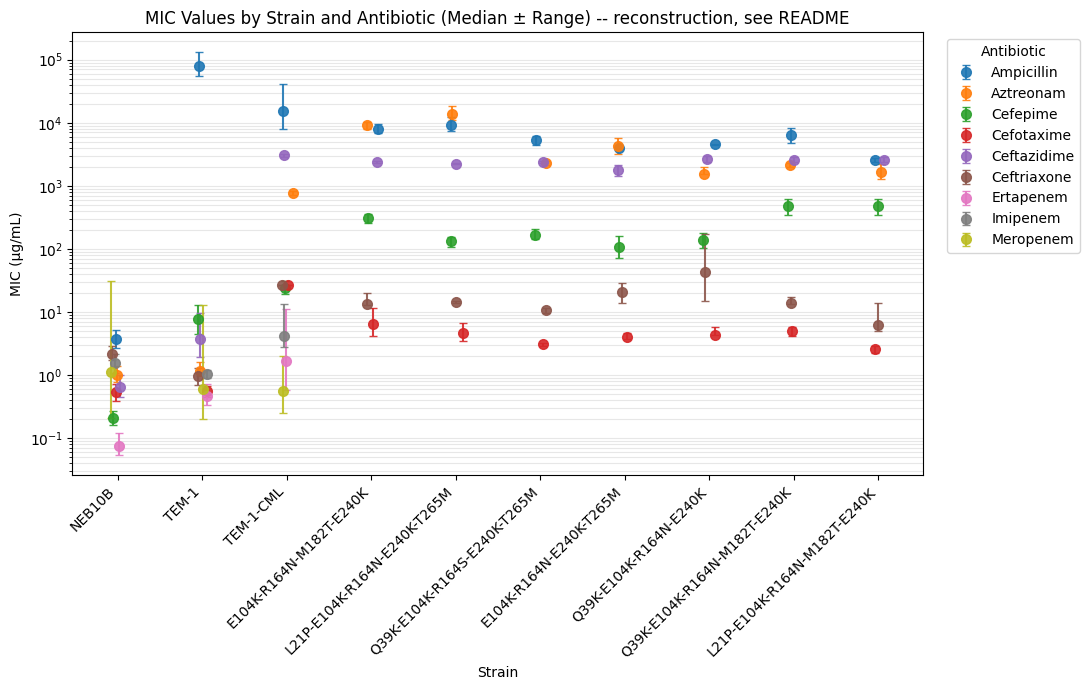

In [29]:
strain_order = [
    'NEB10B', 'TEM-1', 'TEM-1-CML',
    'E104K-R164N-M182T-E240K', 'L21P-E104K-R164N-E240K-T265M',
    'Q39K-E104K-R164S-E240K-T265M', 'E104K-R164N-E240K-T265M',
    'Q39K-E104K-R164N-E240K', 'Q39K-E104K-R164N-M182T-E240K',
    'L21P-E104K-R164N-M182T-E240K',
]
plot_df = growth_features[growth_features['Strain'].isin(strain_order)].copy()
plot_df['Strain'] = pd.Categorical(plot_df['Strain'], categories=strain_order, ordered=True)
plot_df = plot_df.sort_values(['Strain'])

antibiotics_order = sorted(plot_df['Antibiotic'].unique())
palette = dict(zip(antibiotics_order, sns.color_palette('tab10', n_colors=len(antibiotics_order))))

fig, ax = plt.subplots(figsize=(11, 7))
rng = np.random.default_rng(20250508)  # PlateInfo/ODFinal date stamp, for a reproducible jitter only
for ab in antibiotics_order:
    sub = plot_df[plot_df['Antibiotic'] == ab].dropna(subset=['MIC'])
    if sub.empty:
        continue
    x = sub['Strain'].cat.codes.to_numpy().astype(float)
    x = x + rng.uniform(-0.08, 0.08, size=len(x))
    yerr_lower = (sub['MIC'] - sub['MIC_ci_lower']).clip(lower=0)
    yerr_upper = (sub['MIC_ci_upper'] - sub['MIC']).clip(lower=0)
    ax.errorbar(x, sub['MIC'], yerr=[yerr_lower, yerr_upper], fmt='o', ms=7,
                color=palette[ab], ecolor=palette[ab], capsize=3, label=ab, alpha=0.9)

ax.set_yscale('log')
ax.set_xticks(range(len(strain_order)))
ax.set_xticklabels(strain_order, rotation=45, ha='right')
ax.set_xlabel('Strain')
ax.set_ylabel('MIC (\u00b5g/mL)')
ax.set_title('MIC Values by Strain and Antibiotic (Median \u00b1 Range) -- reconstruction, see README')
ax.legend(title='Antibiotic', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, which='both', axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_PATH / PROJECT_ID / 'figures' / 'MIC_single_panel_reconstruction.png', dpi=200, bbox_inches='tight')
plt.show()
